# EasyVisa Project

## Context:

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective:

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired your firm EasyVisa for data-driven solutions. You as a data scientist have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.


## Data Description

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Importing necessary libraries and data

In [1]:
# To suppress the warnings messages when installing packages using pip, add the -q (quiet) flag.
!pip install -q numpy==1.25.2 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries for model training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Libraries for ensemble models
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

# Library to import high-performance gradient boosting classifier
from xgboost import XGBClassifier

# Library to visualizes decision tree structures
from sklearn.tree import plot_tree

# Libtune to tune model, get different metric scores
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score,f1_score
from sklearn.model_selection import GridSearchCV

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Reading the dataset

In [3]:
# Load dataset from colab drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Read the EasyVisa csv
visa = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/PGPprojects/EasyVisa.csv')

In [5]:
# Make copy of visa dataframe
data = visa.copy()

## Data Overview
- Sanity checks

In [6]:
# view the first and last few rows of the dataset, without any overlap
pd.concat([data.head(5), data.tail(5)])

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.9100,Year,Y,Certified


In [7]:
# Calculate the number of rows and columns.
print(f"\nNumber of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")

# Get information about the DataFrame, including data types and non-null values.
data.info()


Number of rows: 25480
Number of columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [8]:
# Check for missing values in each column.
data.isnull().sum()


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


In [9]:
# Check for duplicate vales in each column.
data.duplicated().sum()

0

In [10]:
# Display unique values count in categorical columns
categorical_summary = {col: visa[col].nunique() for col in visa.select_dtypes(include=['object']).columns}

# Display unique values count in numerical columns
numerical_summary = {col: visa[col].nunique() for col in visa.select_dtypes(include=np.number).columns}

# Show the results
print("Numerical Summary:")
print(numerical_summary)
print("\nCategorical Summary:")
print(categorical_summary)

Numerical Summary:
{'no_of_employees': 7105, 'yr_of_estab': 199, 'prevailing_wage': 25454}

Categorical Summary:
{'case_id': 25480, 'continent': 6, 'education_of_employee': 4, 'has_job_experience': 2, 'requires_job_training': 2, 'region_of_employment': 5, 'unit_of_wage': 4, 'full_time_position': 2, 'case_status': 2}


Sanity Check Observations/Insight:

* Data appears to have loaded properly
* 25480 rows and 12 colums observed
* Numerical (3): no_of_employees, yr_of_estab, prevailing_wage
* Categorical (9): case_id, continent, education_of_employee, has_job_experience, requires_job_training, region_of_employment, unit_of_wage, full_time_position, case_status
* No null/missing values or duplicate values in the dataset
* Observed unique values for categorical & numerical  columns

In [11]:
# Get descriptive statistics for numerical columns only.
data.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [12]:
# Get descriptive statistics for all columns.
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations/Insighits:**

Numerical Columns
* no_of_employees:
  * Mean: ~5,667 employees per company
  * Min: -26 (*likely an error*)
  * Max: 602,069 (outlier)
* yr_of_estab:
  * Range: 1800 - 2016
  * Some very old establishment years might be errors.
* prevailing_wage:
  * Mean: ~\$74,456
  * Min: \$2.14 (*seems unrealistic*)
  * Max: \$319,210


There are possible Data Quality Issues:

  * Negative values in no_of_employees
  * Very low wages in prevailing_wage
  * Establishment years as early as 1800 (*potential errors*)

Wage Distribution:

  * The prevailing wage has a large spread, with wages going from just over \$2
   to over \$300K.

Company Sizes:

  * Some companies have very large employee counts, but the presence of negative values suggests data cleaning may be needed.

## Exploratory Data Analysis (EDA):
Note: Keeping objective in sight - with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

* **Focus will be on the model building aspects for key insights.**
* **Additional EDA can be seen in the <a href = #link1>appendix section</a> for more insights into the dataset.**

####**Leading Questions EDA**:
1. Those with higher education may want to travel abroad for a well-paid job. Does education play a role in Visa certification?

2. How does the visa status vary across different continents?

3. Experienced professionals might look abroad for opportunities to improve their lifestyles and career development. Does work experience influence visa status?

4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

case_status            Certified  Denied
education_of_employee                   
Bachelor's                  6367    3867
Doctorate                   1912     280
High School                 1164    2256
Master's                    7575    2059


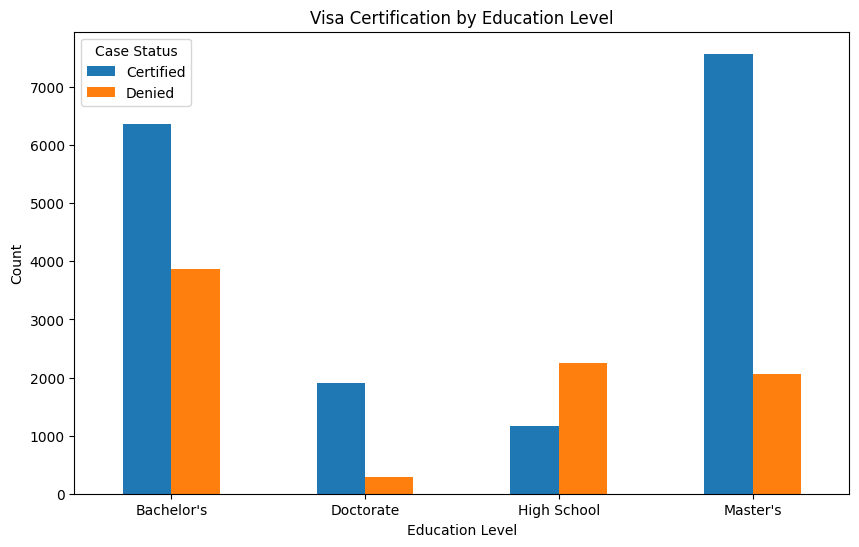


Percentage of certified cases for each education level:
education_of_employee
Bachelor's     62.214188
Doctorate      87.226277
High School    34.035088
Master's       78.627777
dtype: float64

Statement: Higher education generally has a positive correlation with visa certification.


In [13]:
# 1. Does education play a role in Visa certification?

# Analyze the relationship between education and visa certification
education_visa_crosstab = pd.crosstab(data['education_of_employee'], data['case_status'])
print(education_visa_crosstab)

# Visualize the relationship
education_visa_crosstab.plot(kind='bar', figsize=(10, 6))
plt.title('Visa Certification by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Case Status')
plt.show()

# Calculate and print the percentage of certified cases for each education level
certified_percentages = education_visa_crosstab['Certified'] / education_visa_crosstab.sum(axis=1) * 100
print(f"\nPercentage of certified cases for each education level:\n{certified_percentages}")

# Analyze the overall relationship
if certified_percentages.mean() > 50:
  print("\nStatement: Higher education generally has a positive correlation with visa certification.")
else:
  print("\nStatement: Higher education does not appear to significantly influence visa certification.")


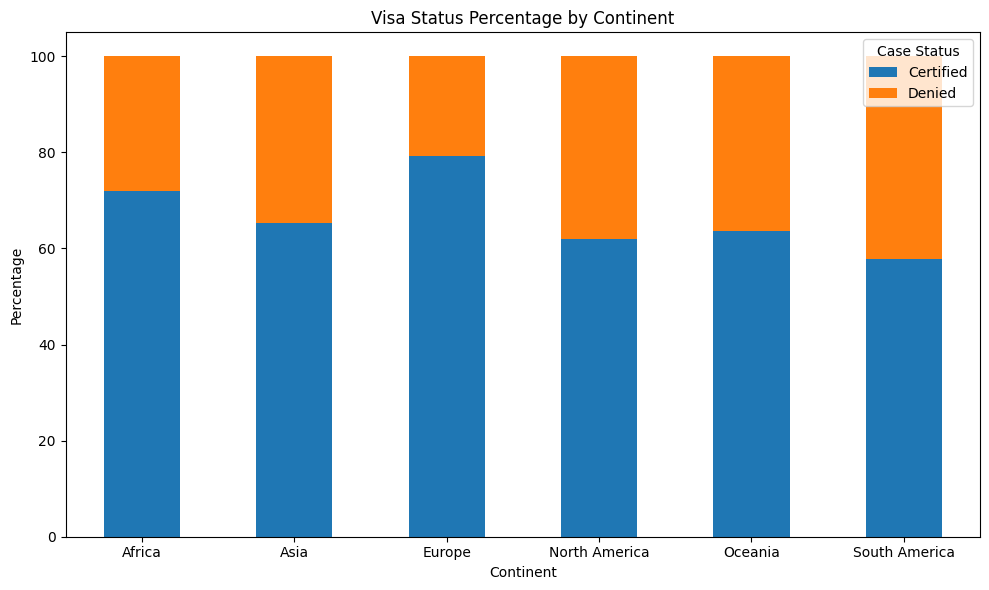

case_status,Certified,Denied
continent,,
Africa,72.050817,27.949183
Asia,65.310480,34.689520
Europe,79.233655,20.766345
North America,61.877278,38.122722
Oceania,63.541667,36.458333
South America,57.863850,42.136150


In [14]:
# 2. How does the visa status vary across different continents?

# Group data by continent and case status, then count occurrences
continent_visa_counts = data.groupby(['continent', 'case_status']).size().unstack(fill_value=0)

# Calculate the percentage of each case status for each continent
continent_visa_percentages = continent_visa_counts.div(continent_visa_counts.sum(axis=1), axis=0) * 100

# Visualize the results
continent_visa_percentages.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Visa Status Percentage by Continent')
plt.xlabel('Continent')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Case Status')
plt.tight_layout()
plt.show()

# Print the results
continent_visa_percentages


Observations:

Visa status varies across different continents as follows-

* Europe has the highest approval rate (79.23%), indicating a higher likelihood of visa certification for applicants from this region.
* Africa follows with 72.05% certification, meaning a relatively high approval rate but lower than Europe.
* Asia has a moderate approval rate (65.31%), showing a slightly higher rejection rate compared to Africa and Europe.
* Oceania (63.54%) and North America (61.87%) have similar approval rates, with slightly more denials.
* South America has the lowest approval rate (57.86%) – meaning applicants from this region experience the highest rejection rates (42.13%).


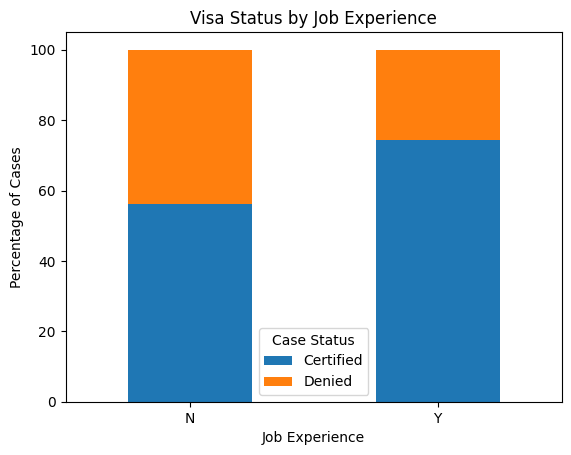

case_status         Certified     Denied
has_job_experience                      
N                   56.134108  43.865892
Y                   74.476422  25.523578

Conclusion:
Having job experience appears to positively influence visa status.


In [15]:
# 3. Does work experience influence visa status?

# Group data by 'has_job_experience' and 'case_status' and count occurrences
experience_visa = data.groupby(['has_job_experience', 'case_status']).size().unstack()

# Calculate the percentage of visa statuses for each experience level
experience_visa_percentage = experience_visa.div(experience_visa.sum(axis=1), axis=0) * 100

# Visualize the relationship between work experience and visa status
experience_visa_percentage.plot(kind='bar', stacked=True)
plt.title('Visa Status by Job Experience')
plt.xlabel('Job Experience')
plt.ylabel('Percentage of Cases')
plt.xticks(rotation=0)
plt.legend(title='Case Status')
plt.show()

# Print the table showing the percentage
print(experience_visa_percentage)

# Analyze the results
# Examine the percentage of certified and denied cases for each level of job experience (Y/N) to draw conclusions.

print("\nConclusion:")
if experience_visa_percentage.loc['Y', 'Certified'] > experience_visa_percentage.loc['N', 'Certified']:
  print("Having job experience appears to positively influence visa status.")
elif experience_visa_percentage.loc['Y', 'Certified'] < experience_visa_percentage.loc['N', 'Certified']:
  print("Having job experience appears to negatively influence visa status.")
else:
  print("There seems to be no significant relationship between job experience and visa status.")


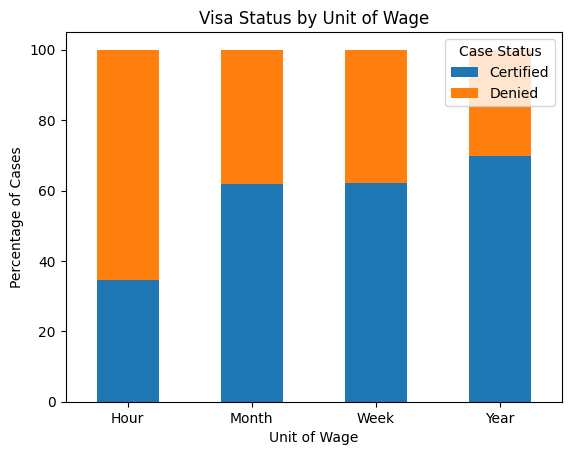

case_status   Certified     Denied
unit_of_wage                      
Hour          34.631433  65.368567
Month         61.797753  38.202247
Week          62.132353  37.867647
Year          69.885027  30.114973

Conclusion:
**The unit of wage most likely to be certified for a visa is: Year**


In [16]:
# 4. In the United States, employees are paid at different intervals. Which pay unit is most likely to be certified for a visa?

# Group data by 'unit_of_wage' and 'case_status' and count occurrences
wage_unit_visa = data.groupby(['unit_of_wage', 'case_status']).size().unstack()

# Calculate the percentage of visa statuses for each wage unit
wage_unit_visa_percentage = wage_unit_visa.div(wage_unit_visa.sum(axis=1), axis=0) * 100

# Visualize the relationship between wage unit and visa status
wage_unit_visa_percentage.plot(kind='bar', stacked=True)
plt.title('Visa Status by Unit of Wage')
plt.xlabel('Unit of Wage')
plt.ylabel('Percentage of Cases')
plt.xticks(rotation=0)
plt.legend(title='Case Status')
plt.show()

# Print the table showing the percentage
print(wage_unit_visa_percentage)

print("\nConclusion:")
max_certified_wage_unit = wage_unit_visa_percentage['Certified'].idxmax()
print(f"**The unit of wage most likely to be certified for a visa is: {max_certified_wage_unit}**")


Observations & Insights:

Higher Denial Rate for Hourly Wages:

* The proportion of denied cases is significantly higher (65.37%) for applicants whose wages are reported hourly compared to other units.
  * This suggests that lower-wage or part-time jobs may have stricter scrutiny or fewer approvals.

Increasing Certification Rates with Longer Wage Units:

* Monthly (61.80%), Weekly (62.13%), and Yearly (69.89%) wages show higher visa approval rates.
  * This indicates that jobs offering stable, long-term salaries are more likely to be certified.

Yearly Wages Have the Highest Approval Rate:

* Applicants reporting annual salaries have the highest certification rate (69.89%) and the lowest denial rate (30.12%).
  * This may be due to yearly wages being associated with full-time, stable employment, which meets visa requirements better.

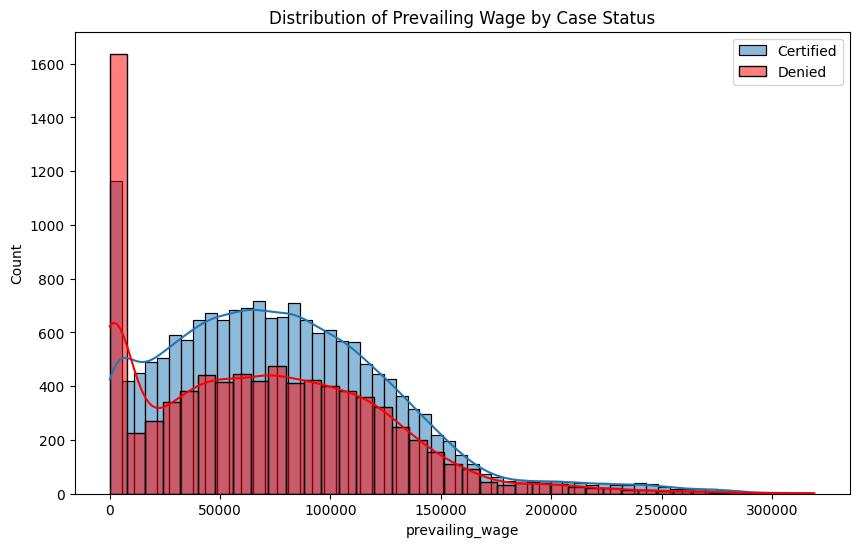

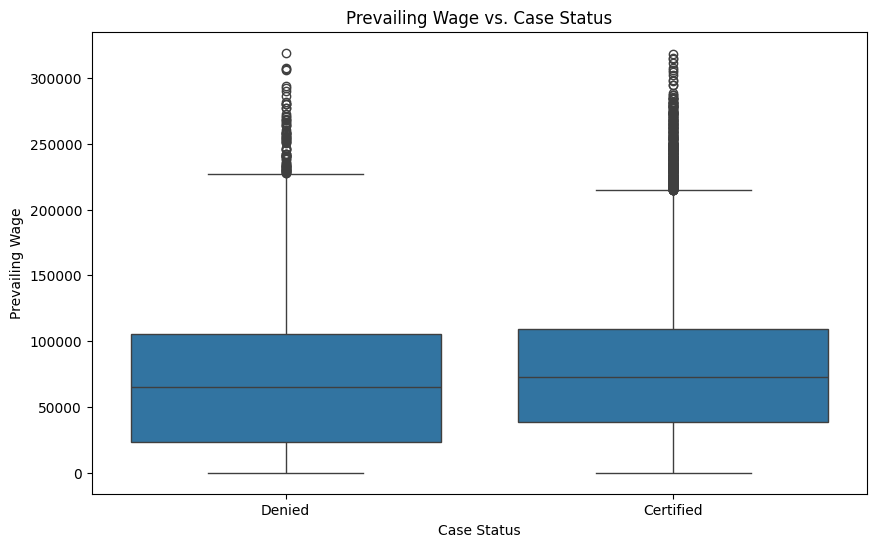

case_status
Certified    77293.619243
Denied       68748.681580
Name: prevailing_wage, dtype: float64


In [17]:
# 5. The US government has established a prevailing wage to protect local talent and foreign workers. How does the visa status change with the prevailing wage?

# Prevailing Wage and Case Status, histplot & boxplot analysis
plt.figure(figsize=(10, 6))
sns.histplot(data[data['case_status'] == 'Certified']['prevailing_wage'], label='Certified', kde=True)
sns.histplot(data[data['case_status'] == 'Denied']['prevailing_wage'], label='Denied', kde=True, color='red')
plt.title('Distribution of Prevailing Wage by Case Status')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6));
sns.boxplot(x='case_status', y='prevailing_wage', data=data)
plt.title('Prevailing Wage vs. Case Status')
plt.xlabel('Case Status')
plt.ylabel('Prevailing Wage')
plt.show()

# Calculate the average prevailing wage for certified and denied cases
print(data.groupby('case_status')['prevailing_wage'].mean())

Observations:

Histplot:

* A large proportion of denied cases (red) are concentrated at lower wage levels (below ~\$30,000).
    * This suggests that applications with lower offered wages are more likely to be rejected
* As wages increase, the proportion of certified cases (blue) rises.
* Certified cases dominate wages above ~\$50,000.
  * This indicates that higher salaries improve the chances of visa approval.
* In the 50,000 dollars - 150,000 dollars range, certified applications consistently outnumber denied ones.
* Beyond \$150,000, denied applications are minimal, suggesting very high wages almost guarantee approval.
* There is a notable spike in denials for extremely low wage cases (close to $0–$10,000).

Boxplot:

* The average prevailing wage for certified cases is 77,293.62 dollars and for denied cases 68,748.68 dollars.
  * This suggests that cases with higher offered wages tend to have a higher probability of being approved.

* Prevailing wage plays a significant role in visa certification—higher wages correlate with higher approval rates.
* Lower wages have a higher risk of denial, possibly due to concerns about labor market impact or failure to meet minimum prevailing wage standards.
* Visa denial is not solely determined by wage—other factors like job classification, employer credibility, and documentation could also influence the outcome.

* Further analysis could involve statistical tests like t-tests to determine if the difference in average prevailing wage between certified and denied cases is statistically significant.


#### **Key Variables EDA:**

In [18]:
# Handling negative values in 'no_of_employees'
data['no_of_employees'] = data['no_of_employees'].apply(lambda x: max(x, 0) if pd.notnull(x) else x)

# Correcting 'yr_of_estab' by setting a minimum valid year (e.g., 1900)
data['yr_of_estab'] = data['yr_of_estab'].apply(lambda x: max(x, 1900) if pd.notnull(x) else x)

# Check descriptive statistics for changes
data.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.00000,25480.000000
mean,5667.066209,1982.53124,74455.814592
std,22877.923141,33.52865,52815.942327
min,0.000000,1900.00000,2.136700
25%,1022.000000,1976.00000,34015.480000
50%,2109.000000,1997.00000,70308.210000
75%,3504.000000,2005.00000,107735.512500
max,602069.000000,2016.00000,319210.270000


Observations/Insights:
* Observed now minimum no of employee (0) and minimum yr of estab (1900)

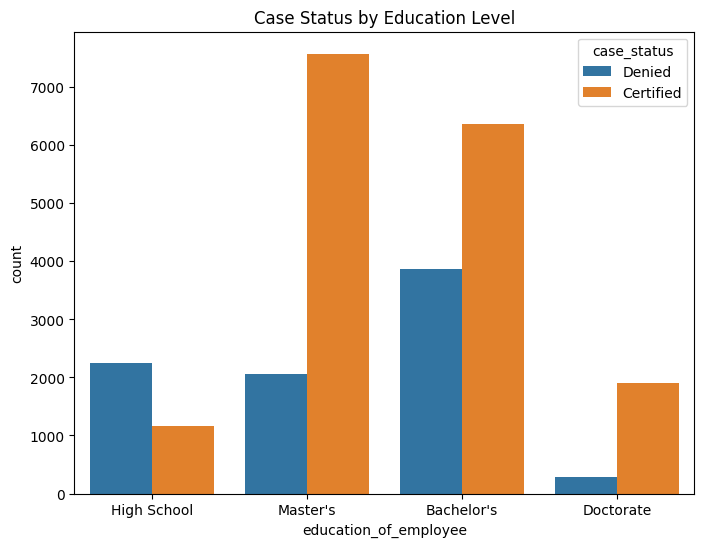

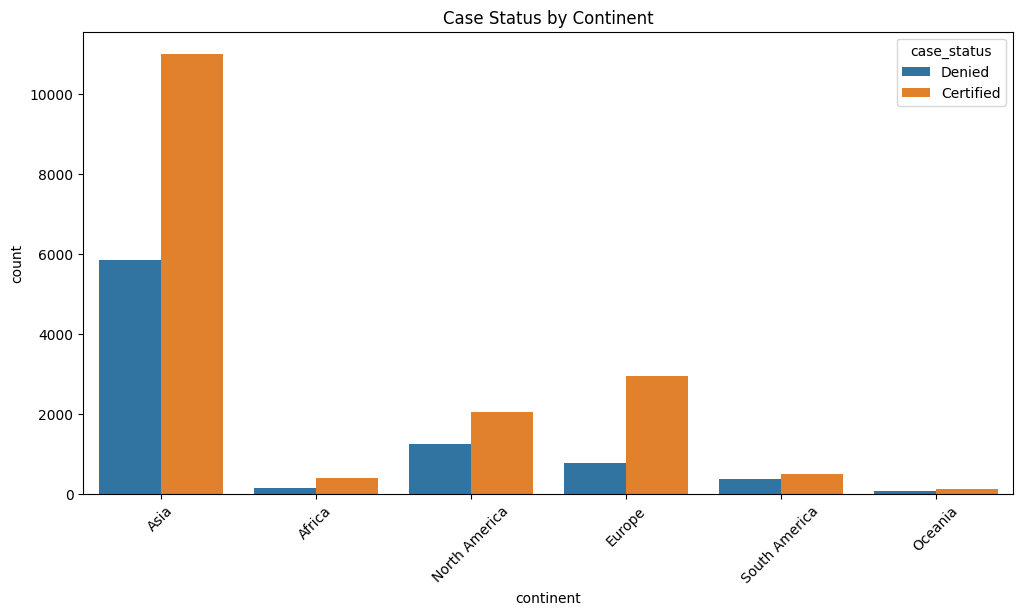

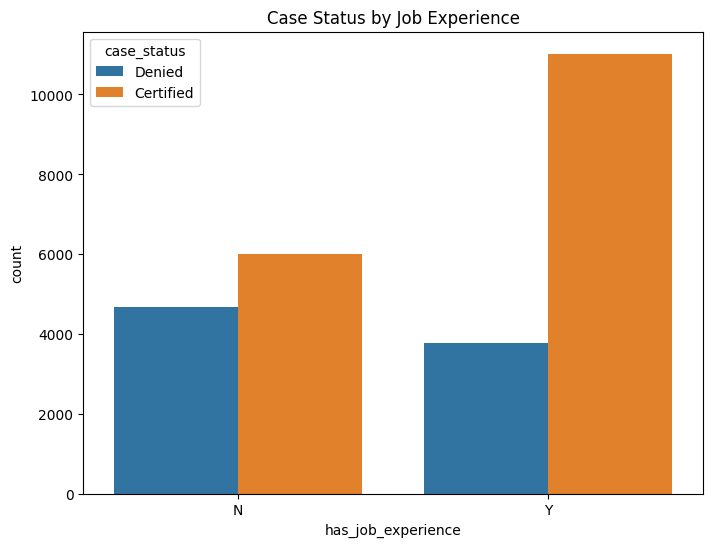

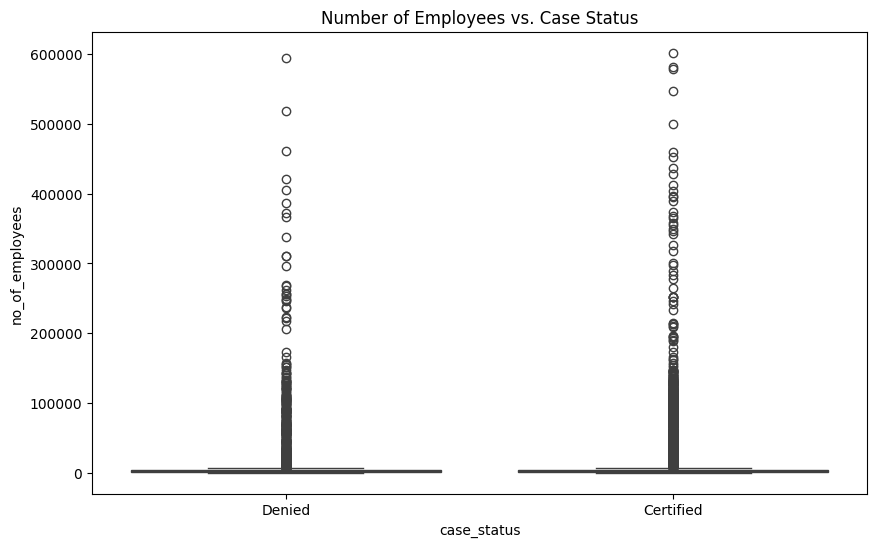

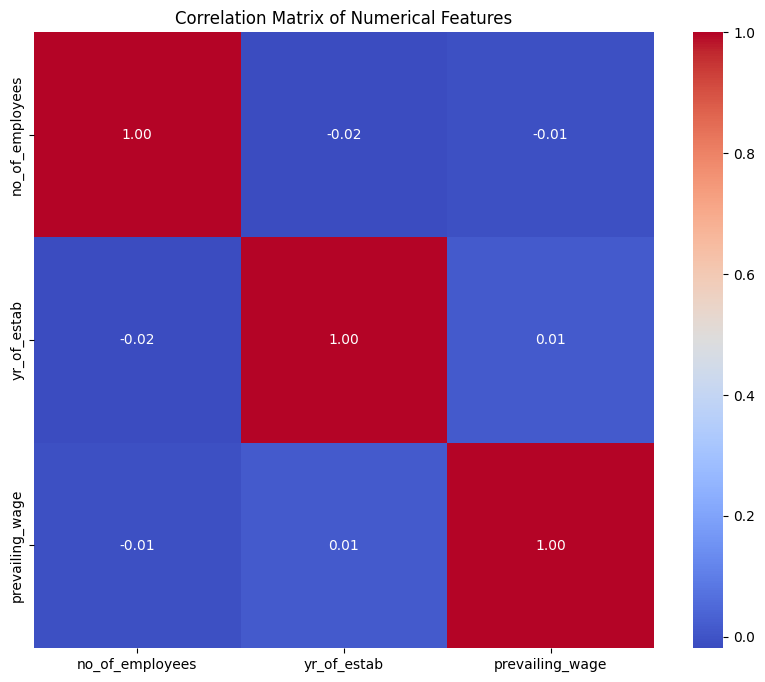

In [19]:
# 1. Education and Case Status
plt.figure(figsize=(8, 6))
sns.countplot(x='education_of_employee', hue='case_status', data=data)
plt.title('Case Status by Education Level')
plt.show()

# 2. Case Status across Continents
plt.figure(figsize=(12, 6))
sns.countplot(x='continent', hue='case_status', data=data)
plt.title('Case Status by Continent')
plt.xticks(rotation=45)
plt.show()

# 3. Work Experience and Case Status
plt.figure(figsize=(8, 6))
sns.countplot(x='has_job_experience', hue='case_status', data=data)
plt.title('Case Status by Job Experience')
plt.show()

# 4. Relationship between number of employees and case status
plt.figure(figsize=(10, 6))
sns.boxplot(x='case_status', y='no_of_employees', data=data)
plt.title('Number of Employees vs. Case Status')
plt.show()

# 5. Correlation matrix of numerical features
numeric_cols = data.select_dtypes(include=np.number).columns
correlation_matrix = data[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


Observations/Insights:

1. Case Status by Education Level:

* Higher education correlates with higher visa approval rates. Encouraging applicants to pursue Master’s or Doctorate degrees can significantly improve their chances of visa certification.
* Bachelor’s degree holders face moderate risk of rejection, so additional factors like experience, job offer strength, and prevailing wage should be considered.
* High School graduates have the lowest approval rate, indicating that education requirements are a crucial factor in employment-based visa decisions.

2. Case Status by Continent:

* Asia dominates in visa applications, with a relatively high approval rate despite high denials. This trend suggests strong demand for skilled labor from Asia.
* North America has a higher proportion of denials compared to certifications, which may require further analysis on application trends and visa requirements.
* Europe enjoys higher certification rates than denials, possibly due to more favorable visa policies or stronger applicant profiles.
* Africa, South America, and Oceania have lower application volumes, which could be due to fewer applicants or stricter employer demands in these regions.

3. Work Experience and Case Status:

* Job experience significantly improves visa approval chances. Employers and applicants should focus on gaining relevant work experience before applying.
* Applicants without experience face a higher risk of visa denial. They may need to strengthen other aspects of their application, such as education, certifications, or employer sponsorship.
* Policymakers and employers may consider structured internship or training programs to help inexperienced applicants become more eligible for work visas.

4. Relationship between number of employees and case status:

* Both Certified and Denied categories have a large number of extreme outliers (companies with 100,000+ employees).
  * This suggests that large firms are actively filing visa applications, but their case status varies.
* The box portion is very compressed near the bottom, indicating that most visa applicants come from companies with a relatively small number of employees.
* The median number of employees appears to be very low, likely in the range of a few hundred to a few thousand.

5. Correlation matrix of numerical features:

* Company size, wages, and establishment year do not have a strong linear relationship.
  * These features may not be good predictors of visa approval alone.

## Data Preprocessing

- Missing value treatment (if needed),
  * As observed in Sanity Check, there are no missing values.
- Feature engineering, *Will explore...*
- Outlier detection and treatment (if needed), *Will explore...*
- Preparing data for modeling, *Will explore...*
- Any other preprocessing steps (if needed)

####Feature Engineering:

In [20]:
data.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

#####Prevailing Wage Analysis:

* It is essential to handle the prevailing_wage column in a way that improves the model's predictive accuracy.

* Exact working hours per day or days per week might be unknown. However, an informed conversion can be made.

* *Will convert prevailing_wage into a common unit (reasonable assumptions can be made).*

* *Retain unit_of_wage as a categorical feature to capture its separate influence on visa approval.*



In [21]:
# Analyze the dataset and check the structure of prevailing_wage and unit_of_wage, to determine the best preprocessing strategy.
print(data[['prevailing_wage', 'unit_of_wage']].head())

# Check the unique values in unit_of_wage to determine conversion feasibility
unit_of_wage_counts = data["unit_of_wage"].value_counts()
unit_of_wage_counts



   prevailing_wage unit_of_wage
0         592.2029         Hour
1       83425.6500         Year
2      122996.8600         Year
3       83434.0300         Year
4      149907.3900         Year


,unit_of_wage
Year,22962
Hour,2157
Week,272
Month,89


Observations/Insights:

* prevailing_wage: Continuous numerical column.
* unit_of_wage: Categorical column with values such as "Hour," "Year," etc.
* yearly wage is the dominant unit, converting other units to a common yearly wage will improve model consistency, assuming standard work hours.

In [22]:
# 1. Combine 'unit_of_wage' and 'prevailing_wage'
# Create a new feature 'normalized_wage' by converting all wages to an annual basis

def normalize_wage(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']
    if unit == 'Hourly':
        return wage * 40 * 52
    elif unit == 'Weekly':
        return wage * 52
    elif unit == 'Monthly':
        return wage * 12
    else:
        return wage

data['normalized_wage'] = data.apply(normalize_wage, axis=1)

# 2. Create a new feature for the age of the company
data['company_age'] = 2024 - data['yr_of_estab']


# 3. Feature Encoding
# Convert categorical features to numerical using one-hot encoding
data = pd.get_dummies(data, columns=['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position'], drop_first=True)


# 4.  Target Encoding
# Encoding the target variable 'case_status'
data['case_status'] = data['case_status'].map({'Certified': 1, 'Denied': 0})

# 5. Dropping 'case_id' column, unique identifier
data = data.drop(columns=['case_id'])

# Display the updated DataFrame
data.head()

,no_of_employees,yr_of_estab,prevailing_wage,case_status,normalized_wage,company_age,continent_Asia,continent_Europe,continent_North America,continent_Oceania,...,has_job_experience_Y,requires_job_training_Y,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West,unit_of_wage_Month,unit_of_wage_Week,unit_of_wage_Year,full_time_position_Y
0,14513,2007,592.2029,0,592.2029,17,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,2412,2002,83425.6500,1,83425.6500,22,1,0,0,0,...,1,0,0,1,0,0,0,0,1,1
2,44444,2008,122996.8600,0,122996.8600,16,1,0,0,0,...,0,1,0,0,0,1,0,0,1,1
3,98,1900,83434.0300,0,83434.0300,124,1,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,1082,2005,149907.3900,1,149907.3900,19,0,0,0,0,...,1,0,0,0,1,0,0,0,1,1


Observations:

* New features created - normalized wage and company age.
* Categorical features converted to numeric, enncoded target variable
* Dropped case id from 'data' dataframe, its a unique identifier and will present no value to the predictive model.
* Observed data shape 25480 rows remains same, 24 columns now because new features and dummy variables included.

####Outlier Detection:

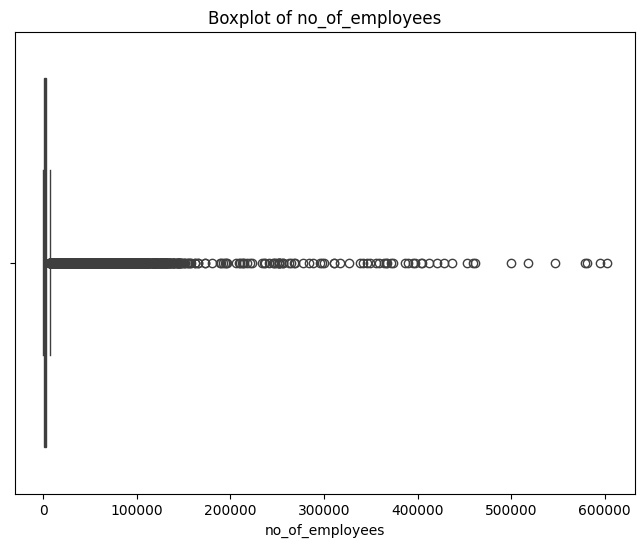

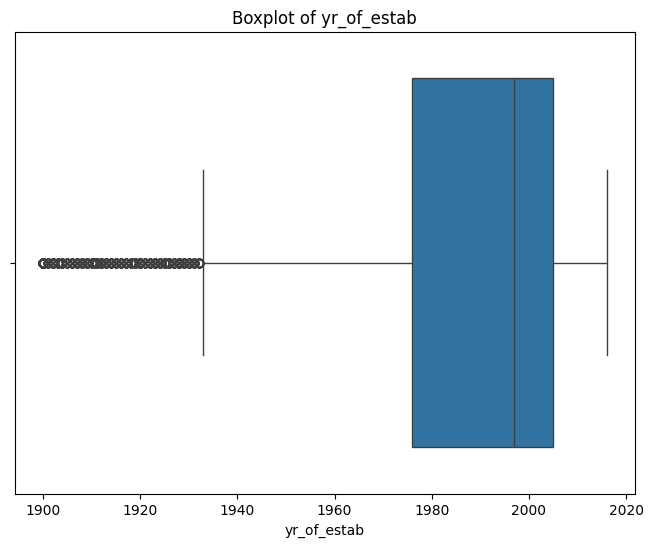

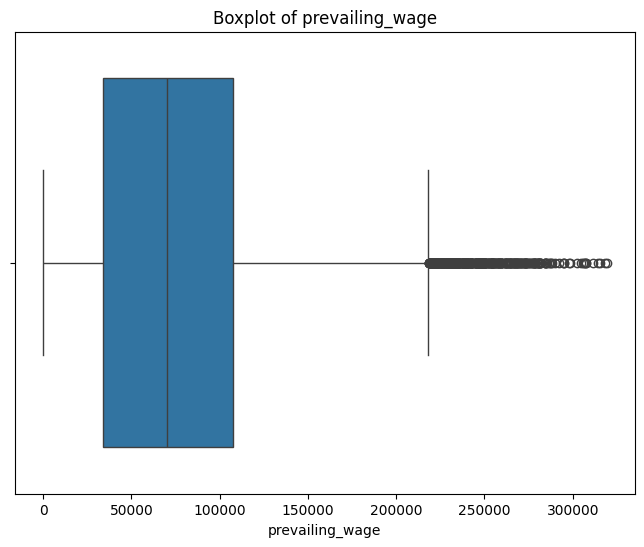

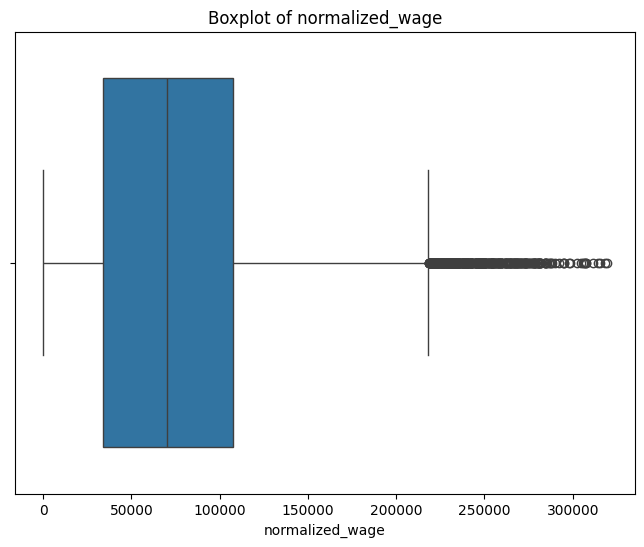

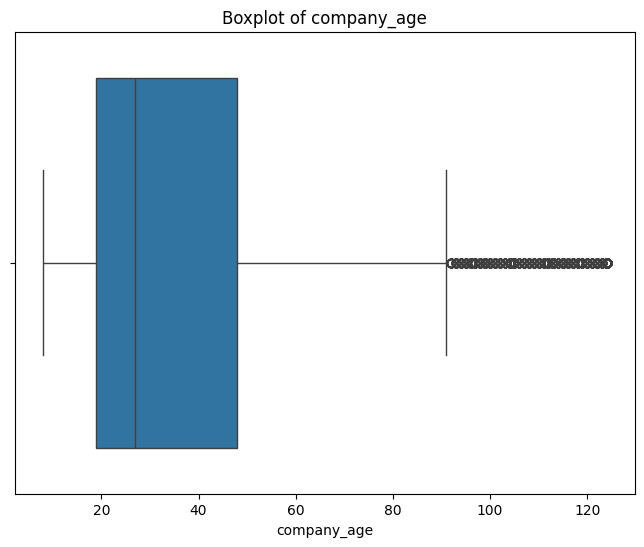

In [23]:
# Check for outliers using boxplots for numerical features
numerical_features = ['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'normalized_wage', 'company_age']

for col in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


Observations:

* Outliers detected i nuemrical features - 'no_of_employees', 'yr_of_estab', 'prevailing_wage', 'normalized_wage', 'company_age'.
* *Outliers may distort the predictive value of the model so will treat by capping ...*

####Outlier Treatment:

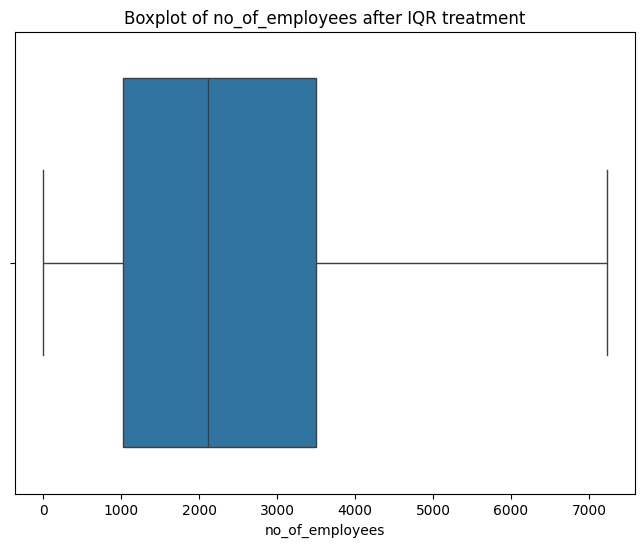

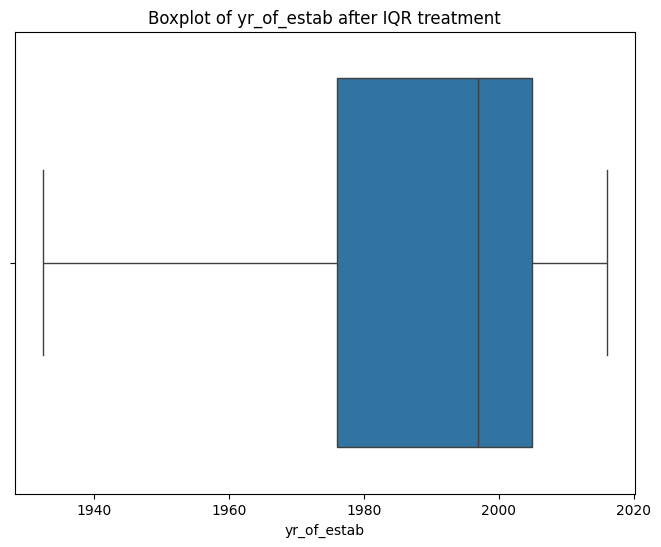

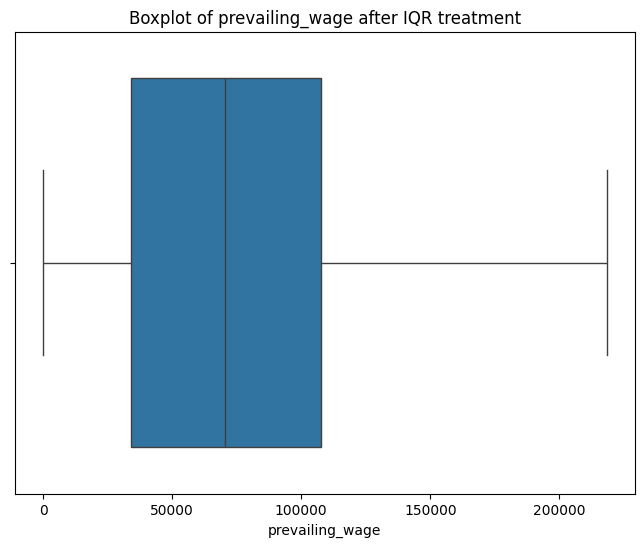

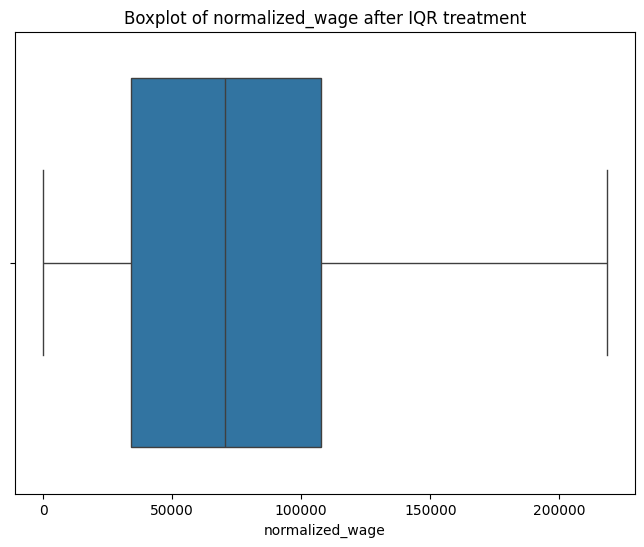

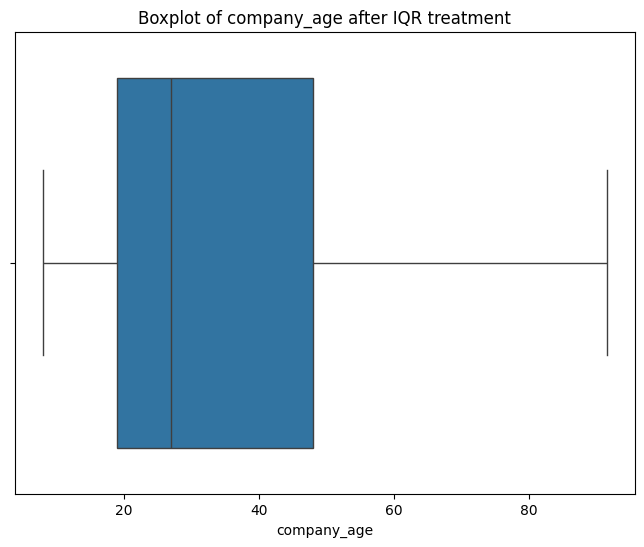

In [24]:
# Cap outliers using IQR method, visualize treated  outliers

def treat_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

for col in numerical_features:
    data = treat_outliers_iqr(data, col)

# Visualize treated outliers using boxplots
for col in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[col])
    plt.title(f'Boxplot of {col} after IQR treatment')
    plt.show()


Observations:

* Outliers capped using IQR method.

## EDA After Data Preprocessing:

- It is a good idea to explore the data once again after manipulating it.

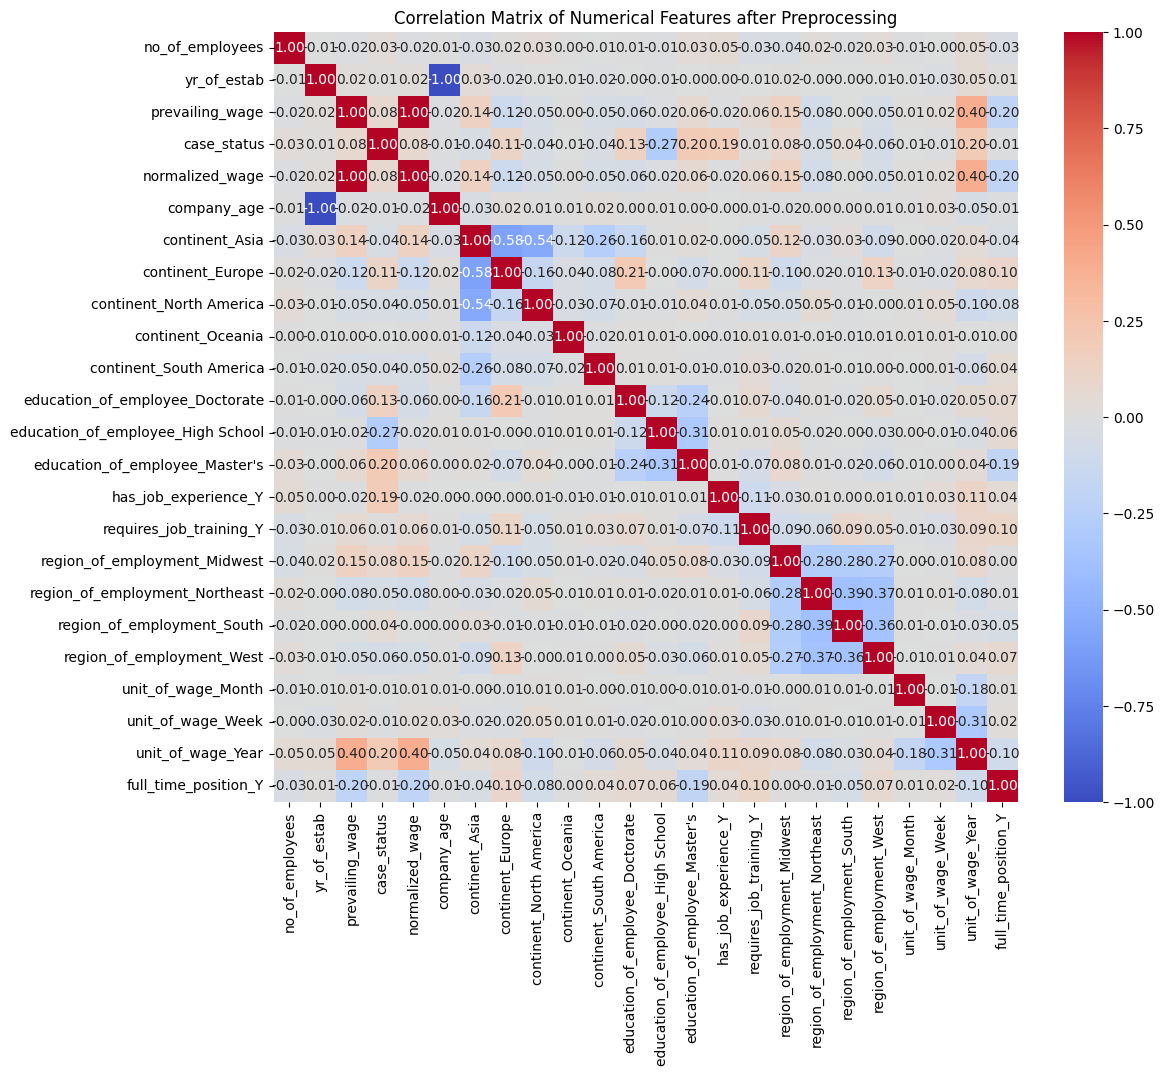

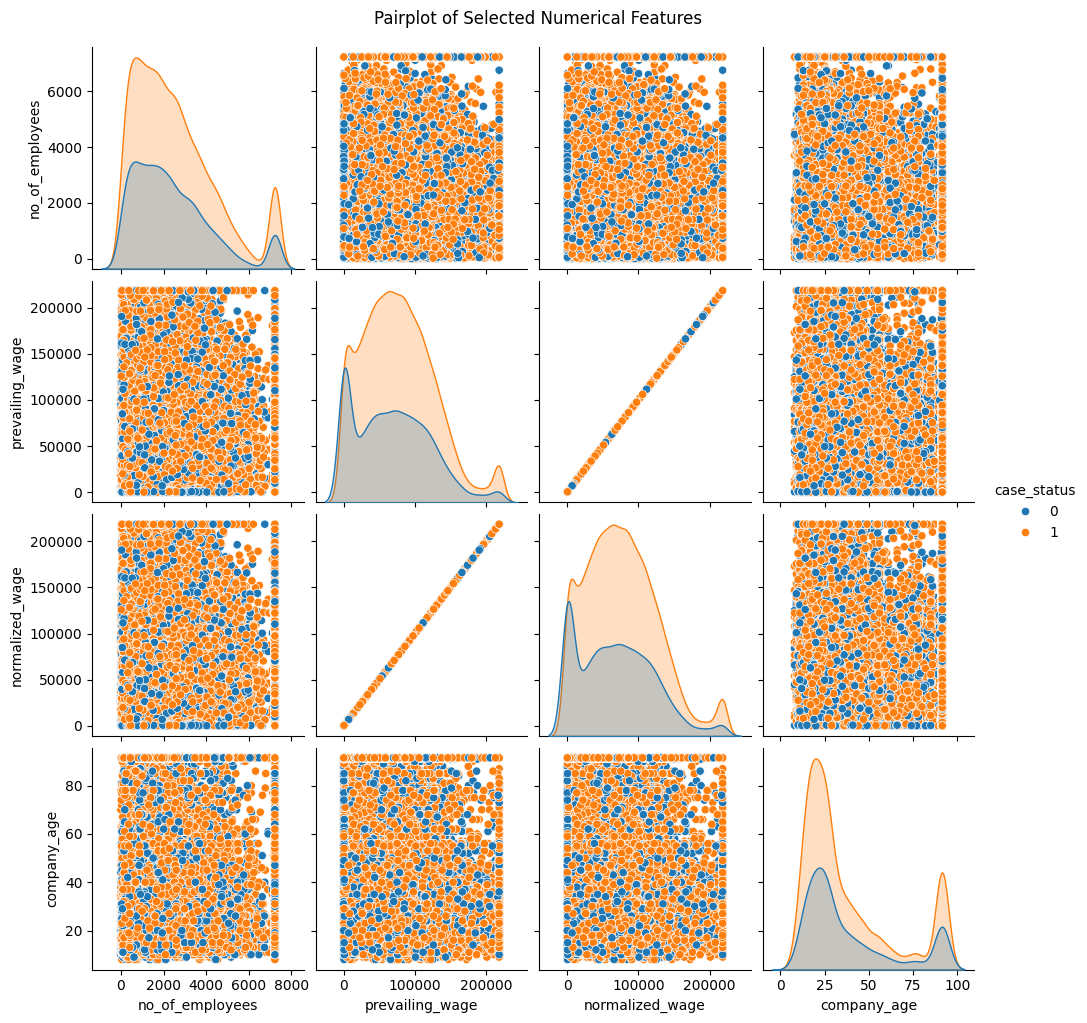

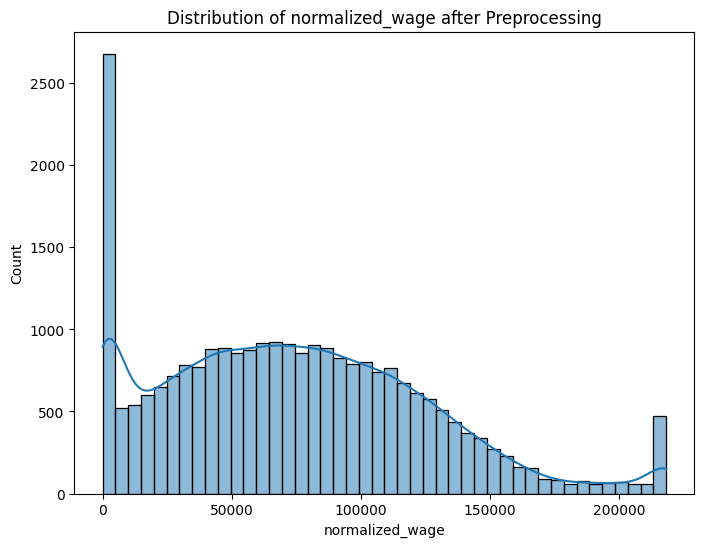

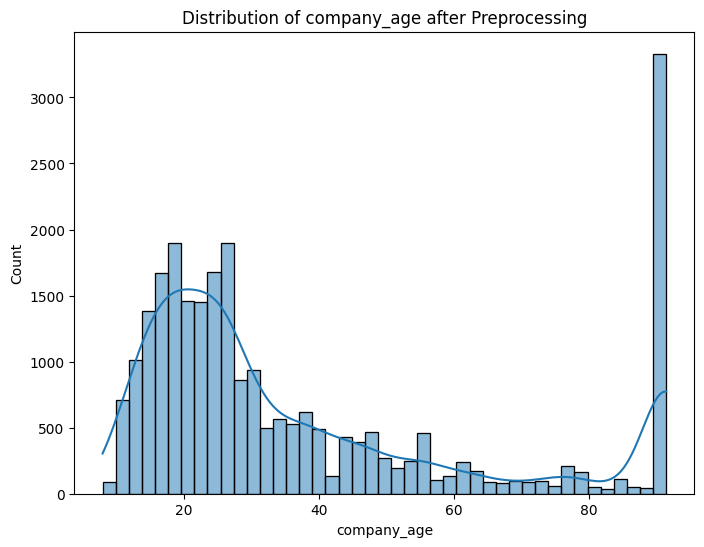

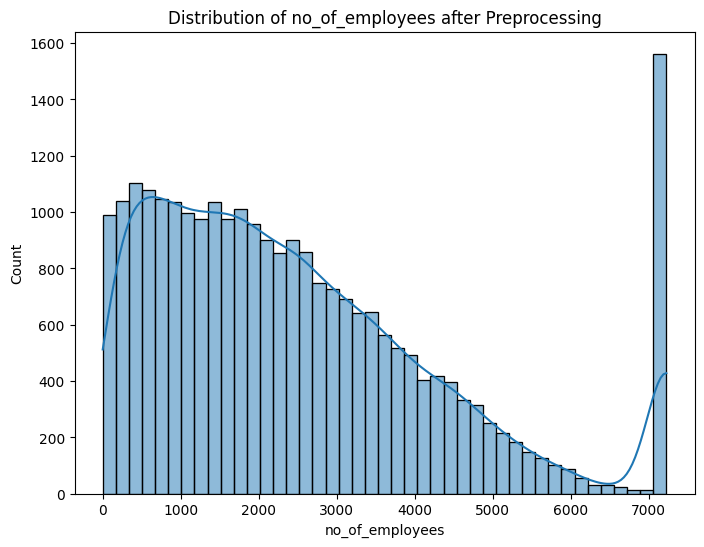

In [25]:
# Explore the data once again after manipulating it.

# 1. Correlation matrix of numerical features after preprocessing
numeric_cols = data.select_dtypes(include=np.number).columns
correlation_matrix = data[numeric_cols].corr()
plt.figure(figsize=(12, 10));
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features after Preprocessing')
plt.show()

# 2. Pairplot of selected numerical features after preprocessing
selected_numerical_cols = ['no_of_employees', 'prevailing_wage', 'normalized_wage', 'company_age', 'case_status']
sns.pairplot(data[selected_numerical_cols], hue='case_status', diag_kind='kde')
plt.suptitle('Pairplot of Selected Numerical Features', y=1.02)
plt.show()

# 3. Distribution of key features after preprocessing
for col in ['normalized_wage', 'company_age', 'no_of_employees']:
    plt.figure(figsize=(8, 6));
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col} after Preprocessing')
    plt.show()


Observations/Insights:

1. Correlation Matrix Heatmap:

 High correlation (close to 1) between prevailing_wage and normalized_wage suggests redundancy.
* Some negative correlations, but most variables are weakly correlated.
region_of_employment categories show some moderate correlation.

2. Pairplot of Selected Features:

    * Orange (1) → Certified
    * Blue (0) → Denied

* prevailing_wage and normalized_wage have a perfect linear correlation (expected).
* Distributions of no_of_employees, company_age, and wage show varied densities based on case_status.

3. Histograms for Distributions:

Normalized Wage Distribution:
* Right-skewed with a high peak at low wages.
* Some extreme values on the higher end.

Company Age Distribution:
* Peaks at lower company ages (10-30 years).
* Another spike at very old companies (90 years), possibly indicating data grouping.

Number of Employees Distribution:
* Right-skewed with a peak at lower employee numbers.
* A second peak at the highest employee numbers (~7000), indicating a bimodal pattern.


##Data Preparation for Modeling:

In [26]:
# Preparing data for modeling, 70:30 ratio, stratification, random state 1

X = data.drop('case_status', axis=1)  # Drop the target column to keep only features
y = data['case_status']  # Extract the target variable (case status)


# Split data into training and testing sets with stratification and random state
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y) # stratify=y: Ensures class balance in both training & test sets.

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17836, 23), (7644, 23), (17836,), (7644,))

Observation:
* Data is ready for modeling.
* Train Data: 17836 rows, 23 features.
* Test Data: 7644 rows, 23 features.
* Balanced Split, there are no missing target values.

#Building Bagging and Boosting Models

###Model Evaluation Criteria:

**Model Evaluation Criteria Based on Business Objective:**

Since the goal is to facilitate visa approvals and recommend a suitable applicant profile, the evaluation criteria should be aligned with decision-making priorities:

* Minimize wrongful denials (False Negatives - FN). Metric to optimize: Recall (Sensitivity)
* Minimize fraudulent or incorrect approvals (False Positives - FP). Metric to optimize: Precision
* Balance both aspects for fair decision-making. Metric to optimize: F1-Score (Harmonic mean of Precision & Recall)
* Ensure overall decision-making power.Metric to optimize: ROC-AUC Score (Evaluates the model’s ability to differentiate between Certified vs. Denied)

**Which Case is More Important?**

* If the goal is to ensure more approvals for genuine applicants → Focus on Recall.
* If the goal is to minimize incorrect approvals → Focus on Precision.
* **Since there is some class imbalance, the F1-score is a good balanced metric.**
*  **F1-score should be prioritized as it balances both Precision and Recall.**

**How to Reduce Losses?**
* Use a Cost-Sensitive Model. Assign a higher penalty for False Negatives ( Logistic Regression with class weights).
* Optimize the Decision Threshold. Instead of a default 0.5 cutoff, adjust based on business impact.
* Feature Importance Analysis. Identify key factors influencing visa decisions (e.g., education level, work experience, wage).
* Use an Ensemble Model for Stability.
Combine models (e.g., Random Forest + Gradient Boosting) to minimize overfitting and increase reliability.




###Defining Functions to Compute Metrics:

In [27]:
# Defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, X, y):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables X
    target: dependent variable y
    """

def model_performance_classification_sklearn(model, X, y):
    y_pred = model.predict(X)
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1 Score": f1_score(y, y_pred),
    }

    # Creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [28]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#####Some parameters to use (will define others as being used):

* Model Initialization & General Settings: init, base_estimator
* Tree Growth & Regularization: max_depth, max_leaf_nodes, min_samples_leaf, min_child_weight, min_impurity_decrease
* Splitting Criteria: gini, entropy, log_loss
* Boosting Control: learning_rate, gamma
* Sampling & Features: bootstrap, bootstrap_features, subsample, max_features, colsample_tree, max_samples
* Number of Trees/Iterations: n_estimators
* OOB Validation: oob

##Models:

####Gradient Boosting:

In [29]:
# Define the parameters grid for Gradient Boosting
param_grid = {
    "n_estimators": np.arange(50, 110, 25),  # Controls the number of boosting stages
    "learning_rate": [0.01, 0.1, 0.05],  # Step size shrinkage to prevent overfitting
    "subsample": [0.7, 0.9],  # Fraction of samples for fitting individual base learners
    "max_features": [0.5, 0.7, 1.0]  # Number of features to consider for the best split
}

# Initialize GridSearchCV
gb_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit the model
gb_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.05],
                         'max_features': [0.5, 0.7, 1.0],
                         'n_estimators': array([ 50,  75, 100]),
                         'subsample': [0.7, 0.9]},
             scoring='f1')

Training Performance:
 {'Accuracy': 0.7540928459295806, 'Precision': 0.7770334928229665, 'Recall': 0.8860908251489968, 'F1 Score': 0.8279865087457841}

Test Performance:
 {'Accuracy': 0.7429356357927787, 'Precision': 0.7686516084873375, 'Recall': 0.8799216454456416, 'F1 Score': 0.8205315553931867}


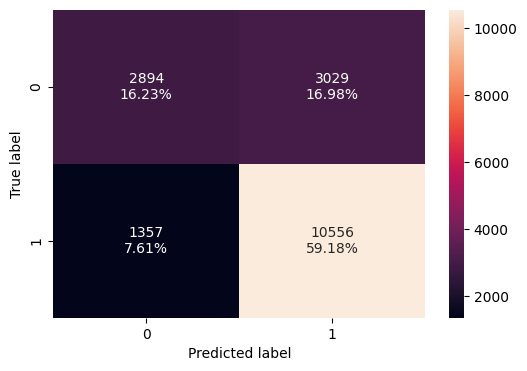

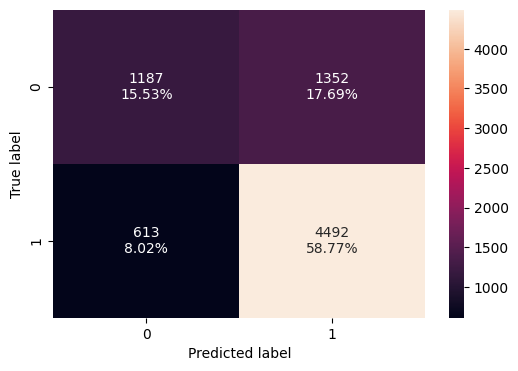

In [30]:
# Get best parameters and best model
best_params = gb_grid.best_params_
best_model = gb_grid.best_estimator_

# Training Performance
gb_grid_train_perf = model_performance_classification_sklearn(best_model, X_train, y_train)
print("Training Performance:\n", gb_grid_train_perf)

# Test Performance
gb_grid_test_perf = model_performance_classification_sklearn(best_model, X_test, y_test)
print("\nTest Performance:\n", gb_grid_test_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_model, X_train, y_train)

# Create confusion matrix Test
confusion_matrix_sklearn(best_model, X_test, y_test)


Observations/Insights:

* The model is well-generalized, showing similar performance on training and test sets.
* It prioritizes recall, meaning it minimizes false negatives but misclassifies some negatives as positives.
* Further tuning can improve precision while maintaining strong recall.

####Adaboost:

In [31]:
# Define the parameters for Adaboost:

param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}


# Initialize GridSearchCV
ada_boost = AdaBoostClassifier()
grid_search_ada = GridSearchCV(estimator=ada_boost, param_grid=param_grid, cv=5, scoring='f1')

# Fit the model
grid_search_ada.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=AdaBoostClassifier(),
             param_grid={'base_estimator': [DecisionTreeClassifier(max_depth=2,
                                                                   random_state=1),
                                            DecisionTreeClassifier(max_depth=3,
                                                                   random_state=1)],
                         'learning_rate': [0.01, 0.1, 0.05],
                         'n_estimators': array([ 50,  75, 100])},
             scoring='f1')

Training Performance:
 {'Accuracy': 0.7535882484862076, 'Precision': 0.7735011641443539, 'Recall': 0.8923864685637539, 'F1 Score': 0.8287017188291694}

Test Performance:
 {'Accuracy': 0.7414965986394558, 'Precision': 0.7645865043125317, 'Recall': 0.8856023506366307, 'F1 Score': 0.8206571065529134}


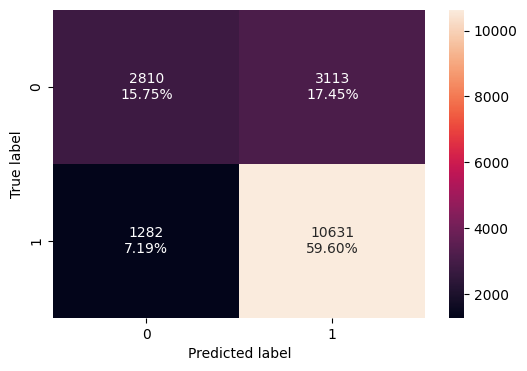

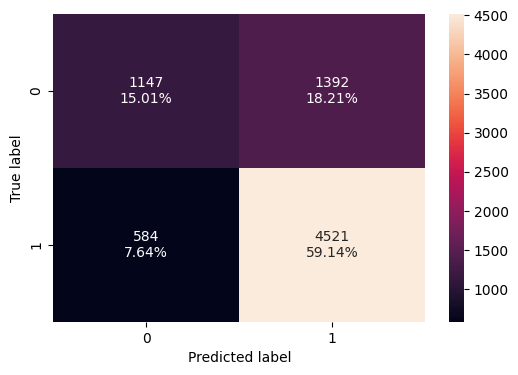

In [32]:
# Get best parameters and best model
best_params_ada = grid_search_ada.best_params_
best_model_ada = grid_search_ada.best_estimator_

# Calculate the different matrix
ada_grid_train_perf=model_performance_classification_sklearn(grid_search_ada.best_estimator_, X_train, y_train)
print("Training Performance:\n",ada_grid_train_perf)

ada_grid_test_perf=model_performance_classification_sklearn(grid_search_ada.best_estimator_, X_test, y_test)
print("\nTest Performance:\n",ada_grid_test_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(grid_search_ada.best_estimator_, X_train, y_train)

# Create confusion matrix Test
confusion_matrix_sklearn(grid_search_ada.best_estimator_, X_test, y_test)


Observations/Insights:

* The test performance is close to training performance, indicating minimal overfitting.
* The high recall (88-89%) but slightly lower precision (76-77%) suggests that the model detects most positive cases but misclassifies some negatives as positives.
* Similar misclassification rates in both training and test sets, confirming a well-generalized model.
* The model prioritizes recall over precision, meaning it catches most positive cases but misclassifies some negatives as positives.
* Further tuning can improve precision while maintaining strong recall

####Bagging Classifier:

In [33]:
# Define the parameters for BaggingClassifier

param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}

# Initialize BaggingClassifier with a DecisionTreeClassifier as the base estimator
bagging_classifier = BaggingClassifier(base_estimator=DecisionTreeClassifier(), random_state=1)

# Initialize and fit GridSearchCV
grid_search_bag = GridSearchCV(estimator=bagging_classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the model
grid_search_bag.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=BaggingClassifier(base_estimator=DecisionTreeClassifier(),
                                         random_state=1),
             n_jobs=-1,
             param_grid={'max_features': [0.7, 0.8, 0.9],
                         'max_samples': [0.8, 0.9, 1],
                         'n_estimators': [30, 50, 70]},
             scoring='f1')

Training Performance:
 {'Accuracy': 0.9991590042610451, 'Precision': 0.998909761824891, 'Recall': 0.9998321161756065, 'F1 Score': 0.9993707261819861}

Test Performance:
 {'Accuracy': 0.7256671899529042, 'Precision': 0.754054054054054, 'Recall': 0.8744368266405484, 'F1 Score': 0.809795918367347}


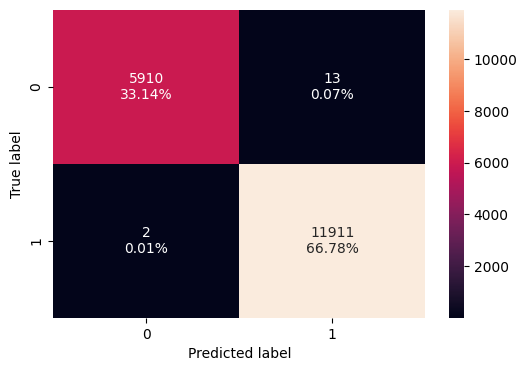

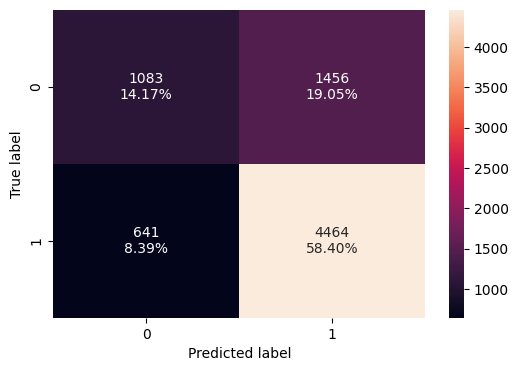

In [34]:
# Get best parameters and best model
best_params_bag = grid_search_bag.best_params_
best_model_bag = grid_search_bag.best_estimator_

# Calculate the different matrix
bag_grid_train_perf = model_performance_classification_sklearn(best_model_bag, X_train, y_train)
print("Training Performance:\n", bag_grid_train_perf)

bag_grid_test_perf = model_performance_classification_sklearn(best_model_bag, X_test, y_test)
print("\nTest Performance:\n", bag_grid_test_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(best_model_bag, X_train, y_train)

# Create confusion matrix Test
confusion_matrix_sklearn(best_model_bag, X_test, y_test)


Observations/Insights:

* The training accuracy is nearly perfect (99.91%), while the test accuracy drops to 72.57%, indicating severe overfitting.
* The test recall (87.44%) is still strong, but the precision is much lower (75.40%), meaning there are many false positives.
* The model fails to generalize well to new data.
* False positives are high (low precision), suggesting overfitting to the training set.

####Random Forest:

In [35]:
# Define the parameters for Random Forest

param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}

# Initialize and fit GridSearchCV
rf_classifier = RandomForestClassifier(random_state=1)
grid_search_rf = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the model
grid_search_rf.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=1), n_jobs=-1,
             param_grid={'max_features': [array([0.3, 0.4, 0.5]), 'sqrt'],
                         'max_samples': array([0.4, 0.5, 0.6]),
                         'min_samples_leaf': array([1, 2, 3]),
                         'n_estimators': [50, 110, 25]},
             scoring='f1')

Training Performance:
 {'Accuracy': 0.8135792778649922, 'Precision': 0.8195891634415005, 'Recall': 0.9243683371107194, 'F1 Score': 0.8688311175983273}

Test Performance:
 {'Accuracy': 0.7424123495552067, 'Precision': 0.771374177916234, 'Recall': 0.8730656219392752, 'F1 Score': 0.8190756225305522}


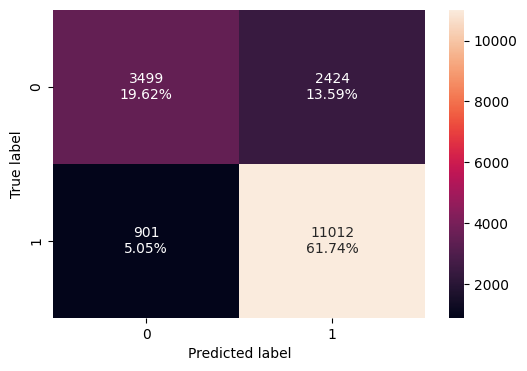

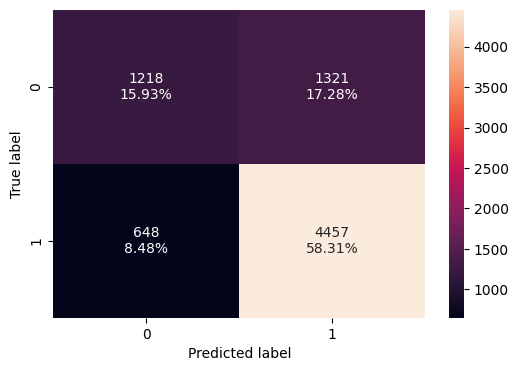

In [36]:
# Get best parameters and best model
best_params_rf = grid_search_rf.best_params_
best_model_rf = grid_search_rf.best_estimator_

# Calculate the different matrix
rf_grid_train_perf=model_performance_classification_sklearn(grid_search_rf.best_estimator_, X_train, y_train)
print("Training Performance:\n",rf_grid_train_perf)

rf_grid_test_perf=model_performance_classification_sklearn(grid_search_rf.best_estimator_, X_test, y_test)
print("\nTest Performance:\n",rf_grid_test_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(grid_search_rf.best_estimator_, X_train, y_train)

# Create confusion matrix Test
confusion_matrix_sklearn(grid_search_rf.best_estimator_, X_test, y_test)


Observations/Insights:

* The test accuracy (74.24%) is noticeably lower than training accuracy (81.36%), indicating some overfitting.
* Recall is high (87.31%), meaning the model effectively detects positive cases.
* Precision is slightly lower (77.13%), meaning there are some false positives.
* F1-score remains fairly high (81.90%), showing a balanced performance.
* False positives increased in the test set, lowering precision.
* False negatives also increased, slightly reducing recall.
* The model generalizes decently but overfits slightly (better recall and precision on training than test).

####Decision Tree:

In [37]:
# Define the paramters for Decision Tree
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=1)

# Create the GridSearchCV object
grid_search_dtree = GridSearchCV(estimator=dtree, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit the model
grid_search_dtree.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=1), n_jobs=-1,
             param_grid={'max_depth': array([2, 3, 4, 5]),
                         'max_leaf_nodes': [10, 15],
                         'min_impurity_decrease': [0.0001, 0.001],
                         'min_samples_leaf': [1, 4, 7]},
             scoring='f1')

Training Performance:
 {'Accuracy': 0.7378335949764521, 'Precision': 0.7479613513328308, 'Recall': 0.9162259716276336, 'F1 Score': 0.8235871123519203}

Test Performance:
 {'Accuracy': 0.7289377289377289, 'Precision': 0.7407525003968884, 'Recall': 0.9140058765915768, 'F1 Score': 0.8183093651350404}


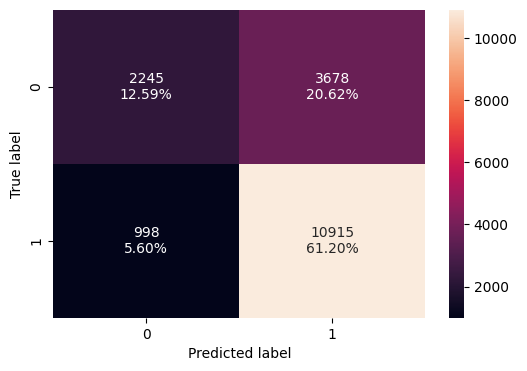

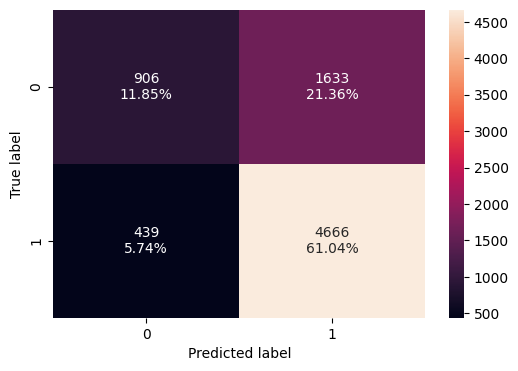

In [38]:
# Get best parameters and best model
best_params_dtree = grid_search_dtree.best_params_
best_model_dtree = grid_search_dtree.best_estimator_

# Calculate the different matrix
dtree_grid_train_perf=model_performance_classification_sklearn(grid_search_dtree.best_estimator_, X_train, y_train)
print("Training Performance:\n",dtree_grid_train_perf)

dtree_grid_test_perf=model_performance_classification_sklearn(grid_search_dtree.best_estimator_, X_test, y_test)
print("\nTest Performance:\n",dtree_grid_test_perf)

# Create confusion matrix Train
confusion_matrix_sklearn(grid_search_dtree.best_estimator_, X_train, y_train)

# Create confusion matrix Test
confusion_matrix_sklearn(grid_search_dtree.best_estimator_, X_test, y_test)

Observations/Insights:

* High recall (91.40%) but lower precision (74.08%) → The model detects most positive cases but struggles with false positives.
* Minimal overfitting → Training and test metrics are close.
* Tuning hyperparameters can improve the balance between recall and precision.


####XGBoost:

In [39]:
# Define the parameters for XGBoost classifier
xgb_model = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}

# Initialize the XGBoost classifier
xgb_model = XGBClassifier(random_state=1, use_label_encoder=False, eval_metric='logloss')

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2)

# Fit the model
grid_search_xgb.fit(X_train, y_train)



Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=1, ...),
             n_jobs=-1,
             param_grid={'gamma': [1, 3], 'learning_rate': [0.01, 0.1, 0.05],
                         'n_estimators': array([ 50,  75, 100]),
                         'scale_pos_weight': [1, 2, 5],
                         'subsample': [0.7, 0.9]},
             scoring='f1', verbose=2)

Training Performance:
 {'Accuracy': 0.7614936084323839, 'Precision': 0.7834357190437421, 'Recall': 0.8885251406027029, 'F1 Score': 0.8326777847702957}

Test Performance:
 {'Accuracy': 0.7446363160648874, 'Precision': 0.7709228389757691, 'Recall': 0.8787463271302645, 'F1 Score': 0.8213108751373123}


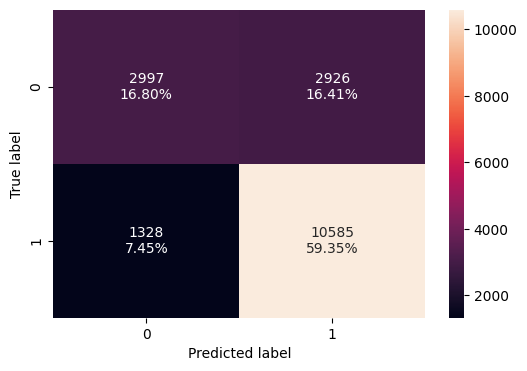

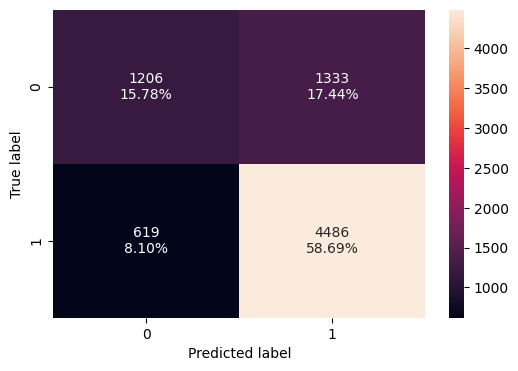

In [40]:
# Get best parameters and best model
best_params_xgb = grid_search_xgb.best_params_
best_xgb_model = grid_search_xgb.best_estimator_

# Calculate the different matrix
xgb_grid_train_perf=model_performance_classification_sklearn(best_xgb_model, X_train, y_train)
print("Training Performance:\n",xgb_grid_train_perf)

xgb_grid_test_perf=model_performance_classification_sklearn(best_xgb_model, X_test, y_test)
print("\nTest Performance:\n",xgb_grid_test_perf)

# Create the confusion matrix Train
confusion_matrix_sklearn(best_xgb_model, X_train, y_train)

# Create the confusion matrix Test
confusion_matrix_sklearn(best_xgb_model, X_test, y_test)


Observations/Insight:

* XGBoost shows strong recall (87.87%) but slightly lower precision (77.09%), meaning the model detects most positives but misclassifies some negatives as positives.
* Overfitting is minimal, as test accuracy (74.46%) closely matches training accuracy (76.15%).
* Hyperparameter tuning can improve precision while maintaining recall balance.

####Stacking classifier:

In [41]:
# Create the Stacking Classifier

# Define the base estimators
estimators = [
    ('gb', gb_grid.best_estimator_),  # Gradient Boosting
    ('ada', grid_search_ada.best_estimator_),  # AdaBoost
    ('bagging', grid_search_bag.best_estimator_),  # Bagging Classifier
    ('rf', grid_search_rf.best_estimator_),  # Random Forest
    ('dtree', grid_search_dtree.best_estimator_),  # Decision Tree
    ('xgb', best_xgb_model)  # XGBoost
]

# Define the meta-learner (model that combines predictions of base estimators)
final_estimator = LogisticRegression()

# Create the StackingClassifier
stacking_model = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

# Fit the stacking model
stacking_model.fit(X_train, y_train)


StackingClassifier(estimators=[('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           max_features=1.0,
                                                           random_state=1,
                                                           subsample=0.9)),
                               ('ada',
                                AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                                                         random_state=1),
                                                   learning_rate=0.05,
                                                   n_estimators=100)),
                               ('bagging',
                                BaggingClassifier(base_estimator=DecisionTreeClassifier(),
                                                  max_features=0.7,
                                                  max...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.05, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=50, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=1, ...))],
                   final_estimator=LogisticRegression())

Stacking Model - Training Performance:
 {'Accuracy': 0.7625588697017268, 'Precision': 0.7896921219438575, 'Recall': 0.8784521111390917, 'F1 Score': 0.8317107093184979}

Stacking Model - Test Performance:
 {'Accuracy': 0.7469911041339613, 'Precision': 0.7780115728563913, 'Recall': 0.8691478942213516, 'F1 Score': 0.8210584752035529}


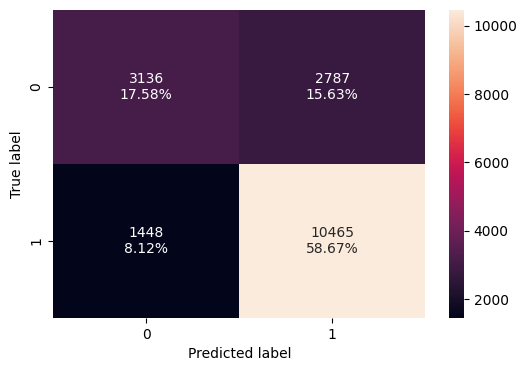

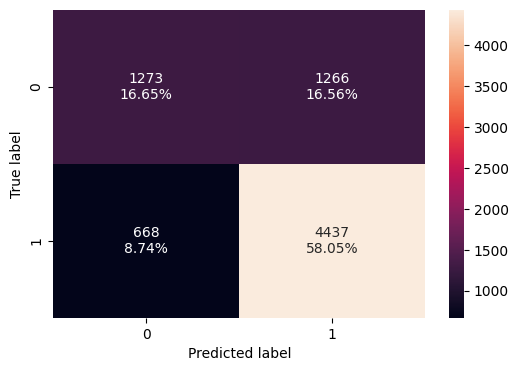

In [42]:
# Evaluate model performance
stacking_train_perf = model_performance_classification_sklearn(stacking_model, X_train, y_train)
print("Stacking Model - Training Performance:\n", stacking_train_perf)

stacking_test_perf = model_performance_classification_sklearn(stacking_model, X_test, y_test)
print("\nStacking Model - Test Performance:\n", stacking_test_perf)

# Create the confusion matrix
confusion_matrix_sklearn(stacking_model, X_train, y_train)
confusion_matrix_sklearn(stacking_model, X_test, y_test)

Observations/Insights:

* The model maintains strong generalization between training and test sets, with minimal performance drop.
* It favors minimizing false negatives, which is useful in applications where missing positive cases is costly.
* The slightly lower precision suggests some false positives, which could be addressed with further tuning or threshold adjustments.
* Overfitting is minimal, as test accuracy (74.69%) is close to training accuracy (76.25%).


###Model Performance Comparision:

In [43]:
# Define models
models = {
    "best_gb": gb_grid.best_estimator_,
    "best_ada_boost": grid_search_ada.best_estimator_,
    "best_bagging_classifier": grid_search_bag.best_estimator_,
    "best_rf_classifier": grid_search_rf.best_estimator_,
    "best_dtree": grid_search_dtree.best_estimator_,
    "best_xgb_model": grid_search_xgb.best_estimator_,
    "stacking_model": stacking_model
}

# Store results
results = []

# Iterate over models to get performance metrics and store results
for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    performance = model_performance_classification_sklearn(model, X_test, y_test) # X_test, y_test
    performance["Model"] = name
    results.append(performance)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display results
results_df

,Accuracy,Precision,Recall,F1 Score,Model
0,0.742936,0.768652,0.879922,0.820532,best_gb
1,0.741497,0.764587,0.885602,0.820657,best_ada_boost
2,0.725667,0.754054,0.874437,0.809796,best_bagging_classifier
3,0.742412,0.771374,0.873066,0.819076,best_rf_classifier
4,0.728938,0.740753,0.914006,0.818309,best_dtree
5,0.744636,0.770923,0.878746,0.821311,best_xgb_model
6,0.746991,0.778012,0.869148,0.821058,stacking_model


Observations/Insights:

Best F1 Score (Balanced Performance):

* Best XGBoost (0.821311) has the highest F1 Score, making it the best balanced model.
* Stacking Model (0.821058) is very close, meaning it also balances well.

Best Precision (Minimizing False Positives):

* Stacking Model (0.778012) has the highest precision.
* Best XGBoost (0.770923) follows closely.

Best Recall (Minimizing False Negatives):

* Best Decision Tree (0.914006) has the highest recall, meaning it identifies more true positives.
* Best AdaBoost (0.885602) is next.






###Will tuning the hyperparameters improve the model performance?

* **Yes, hyperparameter tuning can significantly improve model performance, but the extent depends on various factors such as data quality, feature importance, and model complexity.**
* *Will explore...*

####Tuning Gradient Boosting Model:

In [44]:
# Define the extended parameter grid for tuning Gradient Boosting to improve performance
param_grid = {
    "n_estimators": np.arange(50, 160, 40),  # Increased range for better learning
    "learning_rate": [0.01, 0.1, 0.05],  # Step size shrinkage to prevent overfitting
    "subsample": [0.6, 0.7, 0.9],  # More options for reducing overfitting
    "max_features": [0.3, 0.5, 0.7],  # Additional feature selection values
    "min_samples_split": [2, 5],  # Ensures optimal splits
    "min_samples_leaf": [1, 3],  # Prevents overly complex trees
    "max_depth": [5]  # Deeper trees allow capturing complex patterns
}

# Initialize GridSearchCV
grid_search_gb_tuned = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=1),  # Base model
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Fit the model
grid_search_gb_tuned.fit(X_train, y_train)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=1),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.05], 'max_depth': [5],
                         'max_features': [0.3, 0.5, 0.7],
                         'min_samples_leaf': [1, 3],
                         'min_samples_split': [2, 5],
                         'n_estimators': array([ 50,  90, 130]),
                         'subsample': [0.6, 0.7, 0.9]},
             scoring='f1', verbose=1)

Tuned Gradient Boosting - Training Performance:
 {'Accuracy': 0.7575689616505943, 'Precision': 0.7707069986445031, 'Recall': 0.9068244774615966, 'F1 Score': 0.8332433474739684}

Tuned Gradient Boosting - Test Performance:
 {'Accuracy': 0.7420198848770277, 'Precision': 0.7605188757691668, 'Recall': 0.8957884427032321, 'F1 Score': 0.8226299694189602}


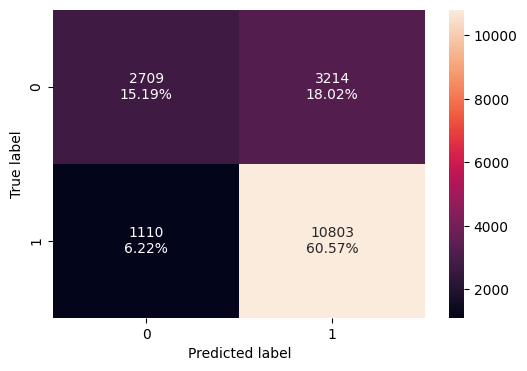

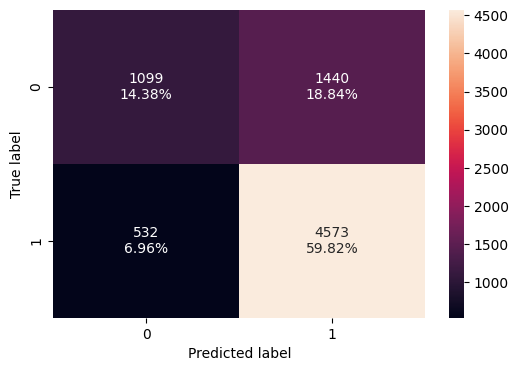

In [45]:
# Get best parameters and best model
best_params = grid_search_gb_tuned.best_params_
best_model = grid_search_gb_tuned.best_estimator_

# Calculate the different matrix
gb_tuned_train_perf = model_performance_classification_sklearn(best_model, X_train, y_train)
print("Tuned Gradient Boosting - Training Performance:\n", gb_tuned_train_perf)

gb_tuned_test_perf = model_performance_classification_sklearn(best_model, X_test, y_test)
print("\nTuned Gradient Boosting - Test Performance:\n", gb_tuned_test_perf)

# Create the confusion matrix for Train and Test
confusion_matrix_sklearn(best_model, X_train, y_train)
confusion_matrix_sklearn(best_model, X_test, y_test)


Observations/Insight:

* The model is performing well with high recall and strong F1-score, making it good for cases where missing a positive instance is costly.
* A slight drop in precision suggests the model may have a slight tendency to classify negative instances as positive.
* The training and test performance metrics are close, meaning no severe overfitting is observed.

####Tuning Adaboost Model:

In [46]:
# Define the extended parameter grid for tuning AdaBoostClassifier to improve performance

param_grid = {
    "n_estimators": np.arange(50, 200, 25),  # Extend the range of estimators
    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.5],  # Add lower & higher rates
    "algorithm": ["SAMME", "SAMME.R"],  # Different boosting algorithms
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, min_samples_leaf=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, min_samples_leaf=3, random_state=1),
        DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=1),
    ],
}

# Initialize AdaBoost with default settings
ada_boost = AdaBoostClassifier(random_state=1)

# Perform GridSearchCV with optimized hyperparameters
grid_search_ada = GridSearchCV(
    estimator=ada_boost, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2
)

# Fit the model
grid_search_ada.fit(X_train, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits


GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=1), n_jobs=-1,
             param_grid={'algorithm': ['SAMME', 'SAMME.R'],
                         'base_estimator': [DecisionTreeClassifier(max_depth=2,
                                                                   min_samples_leaf=2,
                                                                   random_state=1),
                                            DecisionTreeClassifier(max_depth=3,
                                                                   min_samples_leaf=3,
                                                                   random_state=1),
                                            DecisionTreeClassifier(max_depth=4,
                                                                   min_samples_leaf=5,
                                                                   random_state=1)],
                         'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.5],
                         'n_estimators': array([ 50,  75, 100, 125, 150, 175])},
             scoring='f1', verbose=2)

Tuned AdaBoost - Training Performance:
 {'Accuracy': 0.7539807131643866, 'Precision': 0.7758633330889362, 'Recall': 0.8882733148661126, 'F1 Score': 0.8282717595491548}

Tuned AdaBoost - Test Performance:
 {'Accuracy': 0.7414965986394558, 'Precision': 0.7666609851712971, 'Recall': 0.8810969637610186, 'F1 Score': 0.8199052132701422}


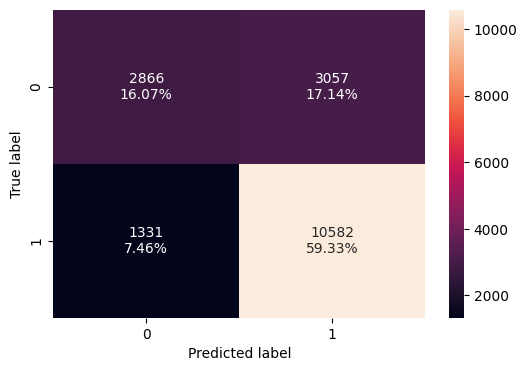

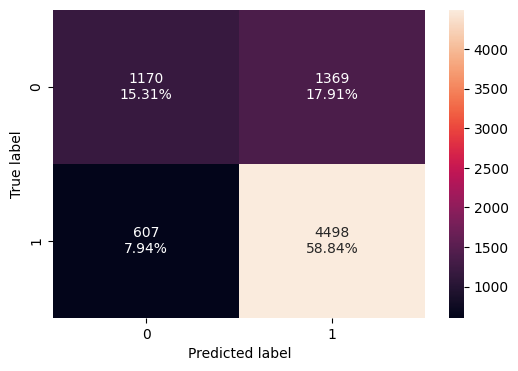

In [47]:
# Get the best model and parameters
best_params_ada = grid_search_ada.best_params_
best_ada_model = grid_search_ada.best_estimator_

# Calculate the different matrix
ada_tuned_train_perf = model_performance_classification_sklearn(best_ada_model, X_train, y_train)
print("Tuned AdaBoost - Training Performance:\n", ada_tuned_train_perf)

ada_tuned_test_perf = model_performance_classification_sklearn(best_ada_model, X_test, y_test)
print("\nTuned AdaBoost - Test Performance:\n", ada_tuned_test_perf)

# Create the confusion matrix
confusion_matrix_sklearn(best_ada_model, X_train, y_train)
confusion_matrix_sklearn(best_ada_model, X_test, y_test)


Observations/Insight:

* The performance on the test set is close to the training set, indicating the model generalizes well.
* The model has a strong recall, meaning it captures a high proportion of actual positives.
* Precision is slightly lower than recall, meaning some false positives exist.
* Overall, the model performs well, balancing accuracy, recall, and precision, making it a strong classifier.

####Tuning Bagging Classifier:

In [48]:
# Define the extended parameter grid for tuning Bagging Classifier to improve performance
param_grid = {
    'n_estimators': [40, 60, 80],  # More estimators for stability
    'max_samples': [0.7, 0.8, 0.9, 1],  # Introduce more variation in resampling
    'max_features': [0.5, 0.7, 0.9],  # Feature subset selection at each split
    'bootstrap': [True, False],  # Compare bootstrap vs. pasting
    'bootstrap_features': [True, False],  # Bootstrap at feature level
    'base_estimator__max_depth': [3, 5],  # Control tree complexity
    'base_estimator__min_samples_split': [2],  # Optimize tree splits
    'base_estimator__min_samples_leaf': [1],  # Prevent overfitting
}

# Initialize BaggingClassifier with a DecisionTreeClassifier as the base estimator
bagging_classifier = BaggingClassifier(
    base_estimator=DecisionTreeClassifier(random_state=1), random_state=42
)

# Perform GridSearchCV for tuning
grid_search_bag = GridSearchCV(
    estimator=bagging_classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2
)

# Fit the model
grid_search_bag.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5,
             estimator=BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=1),
                                         random_state=42),
             n_jobs=-1,
             param_grid={'base_estimator__max_depth': [3, 5],
                         'base_estimator__min_samples_leaf': [1],
                         'base_estimator__min_samples_split': [2],
                         'bootstrap': [True, False],
                         'bootstrap_features': [True, False],
                         'max_features': [0.5, 0.7, 0.9],
                         'max_samples': [0.7, 0.8, 0.9, 1],
                         'n_estimators': [40, 60, 80]},
             scoring='f1', verbose=2)

Tuned Bagging Classifier - Training Performance:
 {'Accuracy': 0.7417021753756448, 'Precision': 0.7496241629082957, 'Recall': 0.9208427767984555, 'F1 Score': 0.8264587335668813}

Tuned Bagging Classifier - Test Performance:
 {'Accuracy': 0.7303767660910518, 'Precision': 0.7406704617330804, 'Recall': 0.9175318315377081, 'F1 Score': 0.8196692624026599}


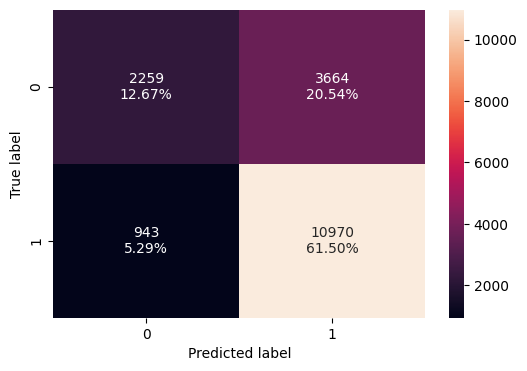

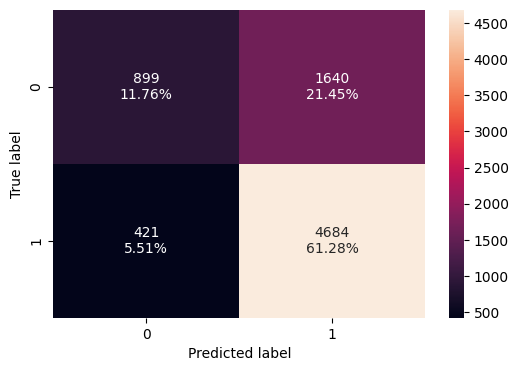

In [49]:
# Get best parameters and best model for Bagging Classifier
best_params_bag = grid_search_bag.best_params_
best_bag_model = grid_search_bag.best_estimator_

# Calculate the performance metrics
bag_tuned_train_perf = model_performance_classification_sklearn(grid_search_bag.best_estimator_, X_train, y_train)
print("Tuned Bagging Classifier - Training Performance:\n", bag_tuned_train_perf)

bag_tuned_test_perf = model_performance_classification_sklearn(grid_search_bag.best_estimator_, X_test, y_test)
print("\nTuned Bagging Classifier - Test Performance:\n", bag_tuned_test_perf)

# Create the confusion matrix
confusion_matrix_sklearn(grid_search_bag.best_estimator_, X_train, y_train)
confusion_matrix_sklearn(grid_search_bag.best_estimator_, X_test, y_test)


Observations/Insight:

* The model demonstrates high recall on both training and test sets (~92% and ~91.75%, respectively). This indicates that the model effectively captures most positive instances.
* The precision is moderate (~74%), meaning there are some false positives. The model is slightly biased towards predicting the positive class.
* The accuracy is around 73%, which is lower than some other models, but the high recall suggests that it minimizes false negatives effectively.
* The F1 score (~82%) shows a well-balanced trade-off between precision and recall.

####Tuning Random Forest:

In [50]:
# Define the extended parameter grid for tuning Random Forest to improve performance
param_grid = {
    "n_estimators": [50, 110, 30],  # Increased range for better performance
    "max_depth": [None, 5],  # Control tree depth for better generalization
    "min_samples_split": [2],  # Optimize number of splits
    "min_samples_leaf": [1, 6],  # Prevent overly complex trees
    "max_features": [0.3, 0.5, 0.6, 'sqrt'],  # More feature selection strategies
    "max_samples": [0.5, 0.7, 0.8],  # Sampling strategies for bagging effect
    "class_weight": [None, "balanced"],  # Handle imbalanced data if needed
}

# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42)

# Perform GridSearchCV for hyperparameter tuning
grid_search_rf = GridSearchCV(
    estimator=rf_classifier, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2
)

# Fit the model
grid_search_rf.fit(X_train, y_train)


Fitting 5 folds for each of 288 candidates, totalling 1440 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'max_depth': [None, 5],
                         'max_features': [0.3, 0.5, 0.6, 'sqrt'],
                         'max_samples': [0.5, 0.7, 0.8],
                         'min_samples_leaf': [1, 6], 'min_samples_split': [2],
                         'n_estimators': [50, 110, 30]},
             scoring='f1', verbose=2)

Tuned Random Forest - Training Performance:
 {'Accuracy': 0.7944606413994169, 'Precision': 0.8066483230460326, 'Recall': 0.910517921598254, 'F1 Score': 0.8554416403785489}

Tuned Random Forest - Test Performance:
 {'Accuracy': 0.7422815279958137, 'Precision': 0.7701189040151646, 'Recall': 0.8754162585700294, 'F1 Score': 0.8193986065273193}


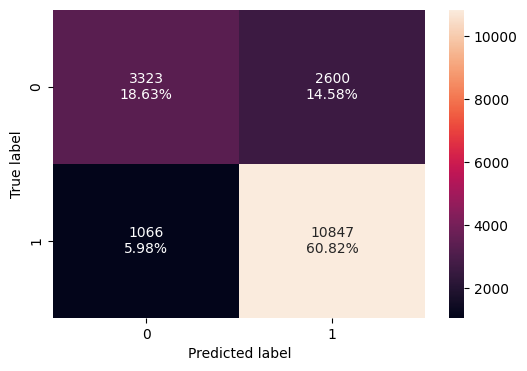

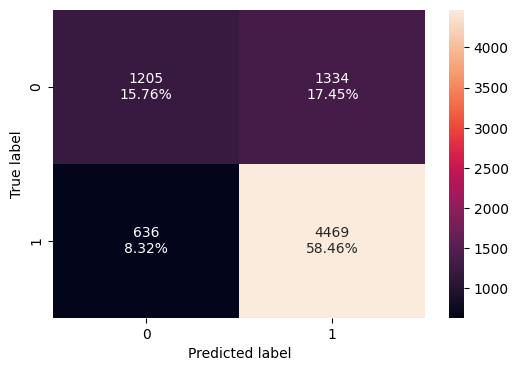

In [51]:
# Get the best model and parameters
best_params_rf = grid_search_rf.best_params_
best_rf_model = grid_search_rf.best_estimator_

# Calculate the performance matrix
rf_tuned_train_perf = model_performance_classification_sklearn(best_rf_model, X_train, y_train)
print("Tuned Random Forest - Training Performance:\n", rf_tuned_train_perf)

rf_tuned_test_perf = model_performance_classification_sklearn(best_rf_model, X_test, y_test)
print("\nTuned Random Forest - Test Performance:\n", rf_tuned_test_perf)

# Create the confusion matrix
confusion_matrix_sklearn(best_rf_model, X_train, y_train)
confusion_matrix_sklearn(best_rf_model, X_test, y_test)


Observations/Insight:

* Both training and test datasets have high recall (0.911 and 0.875, respectively), indicating that the model is very good at identifying the positive class.

* Precision is slightly lower than recall (0.807 for training and 0.770 for test), suggesting some false positives are present.

* The F1 scores (0.855) for training and (0.819) for test, show a good balance between precision and recall.

* The performance metrics are consistent between the training and test datasets, indicating the model generalizes well.

Overall, the tuned Random Forest classifier performs well, especially in identifying the positive class.

####Tuning Decision Tree:

In [52]:
# Define the extended parameter grid for tuning Decision Tree to improve performance
param_grid = {
    'max_depth': [3, 7, None],  # Allow deeper trees for complex relationships
    'min_samples_split': [2],  # Optimize how splits occur
    'min_samples_leaf': [1, 3, 5, 7],  # Ensure minimum samples per leaf to prevent overfitting
    'max_leaf_nodes': [10, 15, None],  # Allow different tree structures
    'min_impurity_decrease': [0.0001, 0.001, 0.01],  # Control purity level to reduce overfitting
    'criterion': ['gini', 'entropy'],  # Test both impurity criteria
    'class_weight': [None, 'balanced']  # Handle class imbalance if needed
}

# Initialize the Decision Tree Classifier
dtree = DecisionTreeClassifier(random_state=42)

# Create the GridSearchCV object
grid_search_dtree = GridSearchCV(
    estimator=dtree, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2
)

# Fit the GridSearchCV object to the training data
grid_search_dtree.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 7, None],
                         'max_leaf_nodes': [10, 15, None],
                         'min_impurity_decrease': [0.0001, 0.001, 0.01],
                         'min_samples_leaf': [1, 3, 5, 7],
                         'min_samples_split': [2]},
             scoring='f1', verbose=2)

Tuned Decision Tree - Training Performance:
 {'Accuracy': 0.7302646333258578, 'Precision': 0.7360409465567668, 'Recall': 0.9294887937547217, 'F1 Score': 0.8215305857476723}

Tuned Decision Tree - Test Performance:
 {'Accuracy': 0.7229199372056515, 'Precision': 0.7295220531735055, 'Recall': 0.9298726738491675, 'F1 Score': 0.8176024801929039}


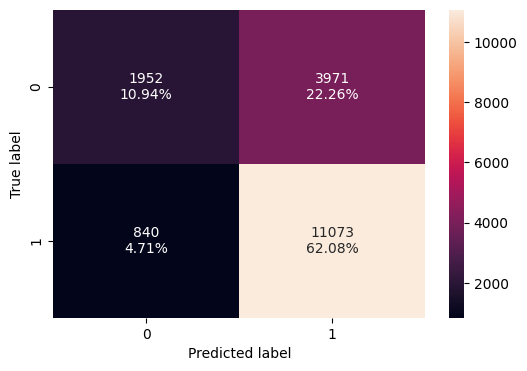

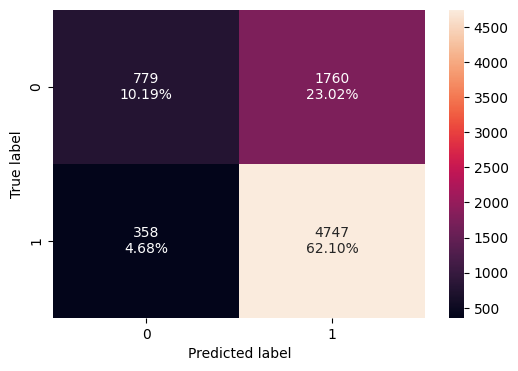

In [53]:
# Get the best model and parameters
best_params_dtree = grid_search_dtree.best_params_
best_dtree_model = grid_search_dtree.best_estimator_

# Calculate the performance matrix
dtree_tuned_train_perf = model_performance_classification_sklearn(best_dtree_model, X_train, y_train)
print("Tuned Decision Tree - Training Performance:\n", dtree_tuned_train_perf)

dtree_tuned_test_perf = model_performance_classification_sklearn(best_dtree_model, X_test, y_test)
print("\nTuned Decision Tree - Test Performance:\n", dtree_tuned_test_perf)

# Create confusion matrix for Train
confusion_matrix_sklearn(best_dtree_model, X_train, y_train)

# Create confusion matrix for Test
confusion_matrix_sklearn(best_dtree_model, X_test, y_test)


Observations/Insight:

* The model demonstrates high recall for both the training (0.9295) and test (0.9299) datasets, indicating it is highly effective at identifying the positive class.

* Precision is slightly lower than recall, with values of 0.7360 for training and 0.7295 for test, indicating the presence of some false positives.

* The F1 scores for training (0.8215) and test (0.8176) suggest a good balance between precision and recall.

* The performance metrics are consistent between training and test datasets, demonstrating good generalization.

Confusion Matrix Analysis
* The model is highly effective at identifying positive cases (True Positives), which suggests it is capturing almost all instances of the positive class



####Tuning XGBoost:

In [54]:
# Define the extended parameter grid for tuning XGBoost to improve performance
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define the extended parameter grid
param_grid = {
    'n_estimators': [50, 120, 30],  # More trees for better learning
    'learning_rate': [0.01, 0.05, 0.1, 0.005],  # Extended learning rate options
    'max_depth': [3],  # Control tree depth
    'min_child_weight': [1],  # Prevents overfitting by requiring min instance weight
    'gamma': [1, 3, 5],  # Minimum loss reduction to split
    'subsample': [0.7, 0.8, 0.9],  # Fraction of samples for training each tree
    'colsample_bytree': [0.6, 0.7],  # Fraction of features per tree
    'reg_alpha': [0.1],  # L1 regularization (reduces feature weights)
    #'reg_lambda': [1, 2, 5, 10],  # L2 regularization (reduces complexity)
    'scale_pos_weight': [1, 2],  # Handles class imbalance
}

# Perform GridSearchCV for hyperparameter tuning
grid_search_xgb = GridSearchCV(
    estimator=xgb_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=2
)

# Fit the model
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.6, 0.7], 'gamma': [1, 3, 5],
                         'learning_rate': [0.01, 0.05, 0.1, 0.005],
                         'max_depth': [3], 'min_child_weight': [1],
                         'n_estimators': [50, 120, 30], 'reg_alpha': [0.1],
                         'scale_pos_weight': [1, 2],
                         'subsample': [0.7, 0.8, 0.9]},
             scoring='f1', verbose=2)

Tuned XGBoost - Training Performance:
 {'Accuracy': 0.7554945054945055, 'Precision': 0.7795380515250222, 'Recall': 0.8839083354318812, 'F1 Score': 0.8284489201840998}

Tuned XGBoost - Test Performance:
 {'Accuracy': 0.7434589220303506, 'Precision': 0.7702888583218707, 'Recall': 0.8775710088148874, 'F1 Score': 0.8204376888563318}


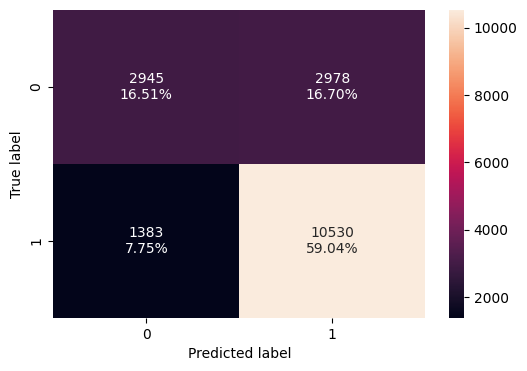

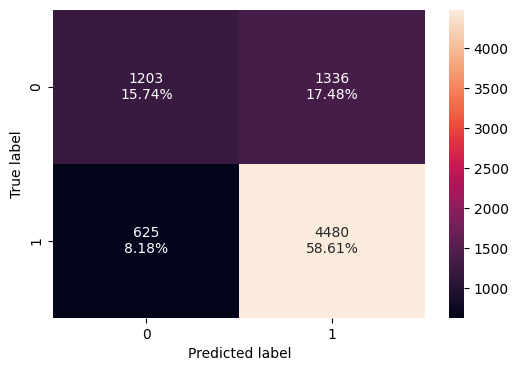

In [55]:
# Get the best model and parameters
best_params_xgb = grid_search_xgb.best_params_
best_xgb_model = grid_search_xgb.best_estimator_

# Evaluate the tuned model
xgb_tuned_train_perf = model_performance_classification_sklearn(best_xgb_model, X_train, y_train)
print("Tuned XGBoost - Training Performance:\n", xgb_tuned_train_perf)

xgb_tuned_test_perf = model_performance_classification_sklearn(best_xgb_model, X_test, y_test)
print("\nTuned XGBoost - Test Performance:\n", xgb_tuned_test_perf)

# Create confusion matrices
confusion_matrix_sklearn(best_xgb_model, X_train, y_train)
confusion_matrix_sklearn(best_xgb_model, X_test, y_test)


Observations/Insights:

* High Recall: The model demonstrates a high recall for both training (0.8839) and test (0.8776) datasets, indicating it's effective at identifying the positive class.

* Moderate Precision: Precision is slightly lower than recall, with values of 0.7795 for training and 0.7703 for test, suggesting the presence of some false positives.

* Balanced F1 Score: The F1 scores for training (0.8284) and test (0.8204) suggest a good balance between precision and recall.

* Consistent Performance: The performance metrics are consistent between training and test datasets, indicating good generalization.

* The tuned XGBoost model performs well, striking a balance between precision and recall. However, mild overfitting suggests that further tuning and ensemble methods may yield even better results.

####Tuning Stacking Classifier:

In [56]:
# Create hyperparameter tuning for Stacking Classifier for improved performance

# Define the base estimators with tuned models
estimators = [
    ('gb', gb_grid.best_estimator_),  # Tuned Gradient Boosting
    ('ada', grid_search_ada.best_estimator_),  # Tuned AdaBoost
    ('bagging', grid_search_bag.best_estimator_),  # Tuned Bagging Classifier
    ('rf', grid_search_rf.best_estimator_),  # Tuned Random Forest
    ('dtree', grid_search_dtree.best_estimator_),  # Tuned Decision Tree
    ('xgb', best_xgb_model)  # Tuned XGBoost
]

# Define the meta-learner
meta_learners = {
    "log_reg": LogisticRegression(max_iter=500),  # Default Logistic Regression
    "xgb": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=1),
    "rf": RandomForestClassifier(n_estimators=100, random_state=1),  # Random Forest
    }

# Initialize and test different meta-learners for stacking
# Initialize stacking_model_tuned outside the loop
stacking_model_tuned = None

for name, final_estimator in meta_learners.items():
  print(f"\nTraining Stacking Classifier with {name} as meta-learner...")

# Create the StackingClassifier
stacking_model_tuned = StackingClassifier(estimators=estimators, final_estimator=final_estimator, n_jobs=-1)

# Fit the stacking model
stacking_model_tuned.fit(X_train, y_train)



Training Stacking Classifier with log_reg as meta-learner...

Training Stacking Classifier with xgb as meta-learner...

Training Stacking Classifier with rf as meta-learner...


StackingClassifier(estimators=[('gb',
                                GradientBoostingClassifier(learning_rate=0.05,
                                                           max_features=1.0,
                                                           random_state=1,
                                                           subsample=0.9)),
                               ('ada',
                                AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=3,
                                                                                         min_samples_leaf=3,
                                                                                         random_state=1),
                                                   learning_rate=0.05,
                                                   n_estimators=100,
                                                   random_state=1)),
                               ('bagging',
                                BaggingClassifier(base_estimator=DecisionTre...
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=3,
                                              max_leaves=None,
                                              min_child_weight=1, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=120, n_jobs=None,
                                              num_parallel_tree=None,
                                              random_state=42, ...))],
                   final_estimator=RandomForestClassifier(random_state=1),
                   n_jobs=-1)


Stacking Model (Tuned Stacking Model) - Training Performance:
 {'Accuracy': 0.7552141735815205, 'Precision': 0.7890020678563223, 'Recall': 0.8647695794510198, 'F1 Score': 0.8251501802162594}

Stacking Model (Tuned Stacking Model) - Test Performance:
 {'Accuracy': 0.7257980115122973, 'Precision': 0.7659536856991338, 'Recall': 0.8487757100881489, 'F1 Score': 0.8052406615870656}


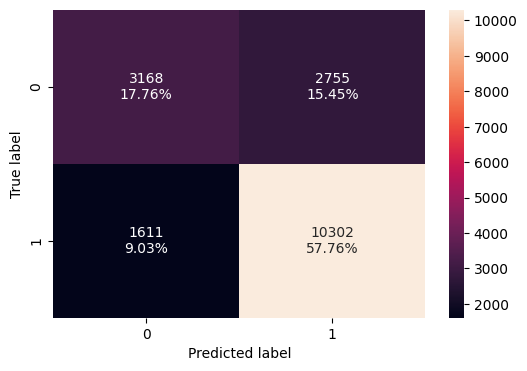

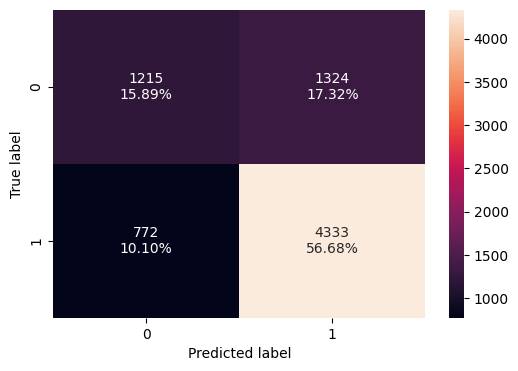

In [74]:
# Get the best model and parameters
best_stacking_model = stacking_model_tuned  # Directly use stacking_model_tuned

# Evaluate model performance inside the loop
stacking_train_perf_tuned = model_performance_classification_sklearn(best_stacking_model, X_train, y_train)
stacking_test_perf_tuned = model_performance_classification_sklearn(best_stacking_model, X_test, y_test)

# Print results
name = "Tuned Stacking Model"
print(f"\nStacking Model ({name}) - Training Performance:\n", stacking_train_perf_tuned)
print(f"\nStacking Model ({name}) - Test Performance:\n", stacking_test_perf_tuned)

# Create confusion matrices
confusion_matrix_sklearn(best_stacking_model, X_train, y_train)
confusion_matrix_sklearn(best_stacking_model, X_test, y_test)


Observations/Insights:

* The F1 score (0.8052 on test data) suggests a good balance between Precision (0.7659) and Recall (0.8487).
* The recall value is higher, indicating that the model is effective at identifying positive cases but at the cost of some false positives.
* The slight drop in F1 Score from 0.8251 (train) to 0.8052 (test) suggests a well-tuned model with minimal overfitting.
* The accuracy (0.7257) remains competitive compared to other models tested.


###Tuned Model Performance Comparision:

In [82]:
# Store results
tuned_results = []

# Define dictionary correctly
tuned_models = {
    'gb': gb_grid.best_estimator_,  # Tuned Gradient Boosting
    'ada': grid_search_ada.best_estimator_,  # Tuned AdaBoost
    'bagging': grid_search_bag.best_estimator_,  # Tuned Bagging Classifier
    'rf': grid_search_rf.best_estimator_,  # Tuned Random Forest
    'dtree': grid_search_dtree.best_estimator_,  # Tuned Decision Tree
    'xgb': best_xgb_model,  # Tuned XGBoost
    'stacking': best_stacking_model  # Tuned Stacking Classifier
}

# Iterate over tuned models to get performance metrics
for name, model in tuned_models.items():
    performance = model_performance_classification_sklearn(model, X_test, y_test)
    performance["Model"] = name
    tuned_results.append(performance)

# Convert results to DataFrame
tuned_results_df = pd.DataFrame(tuned_results)

# Display results
tuned_results_df



,Accuracy,Precision,Recall,F1 Score,Model
0,0.742936,0.768652,0.879922,0.820532,gb
1,0.741497,0.766661,0.881097,0.819905,ada
2,0.730377,0.740670,0.917532,0.819669,bagging
3,0.742282,0.770119,0.875416,0.819399,rf
4,0.722920,0.729522,0.929873,0.817602,dtree
5,0.743459,0.770289,0.877571,0.820438,xgb
6,0.725798,0.765954,0.848776,0.805241,stacking


Observations/Insights:

* Balanced Approach (F1 Score Best)	Gradient Boosting (0.8205)	Best balance between Precision & Recall
* Minimize False Negatives (High Recall)	Decision Tree (0.9299)	Ensures more qualified applicants get approved
* Minimize False Positives (High Precision)

## Model Performance Comparison and Conclusions

* F1-Score is the priority, as it balances Precision (False Positive Rate) and Recall (False Negative Rate).
* The model should generalize well on the test dataset while maintaining high F1-score.

In [84]:
# Define model names and corresponding performance dictionaries
models = ['Gradient Boosting', 'AdaBoost', 'Bagging', 'Random Forest', 'Decision Tree', 'XGBoost', 'Stacking',
          'Tuned Gradient Boosting', 'Tuned AdaBoost', 'Tuned Bagging', 'Tuned Random Forest', 'Tuned Decision Tree', 'Tuned XGBoost',
          'Tuned Stacking']  # Tuned models

# Get performance metrics for stacking models
stacking_train_perf = model_performance_classification_sklearn(stacking_model, X_train, y_train)
stacking_model_train_perf = model_performance_classification_sklearn(tuned_models['stacking'], X_train, y_train)

stacking_test_perf = model_performance_classification_sklearn(stacking_model, X_test, y_test)
stacking_model_test_perf = model_performance_classification_sklearn(tuned_models['stacking'], X_test, y_test)


# Train
train_performance = [
    gb_grid_train_perf, ada_grid_train_perf, bag_grid_train_perf,
    rf_grid_train_perf, dtree_grid_train_perf, xgb_grid_train_perf,
    stacking_train_perf,  # Base Stacking
    gb_tuned_train_perf, ada_tuned_train_perf, bag_tuned_train_perf,
    rf_tuned_train_perf, dtree_tuned_train_perf, xgb_tuned_train_perf,
    stacking_model_train_perf  # Tuned Stacking
]
# Test
test_performance = [
    gb_grid_test_perf, ada_grid_test_perf, bag_grid_test_perf,
    rf_grid_test_perf, dtree_grid_test_perf, xgb_grid_test_perf,
    stacking_test_perf,  # Base Stacking
    gb_tuned_test_perf, ada_tuned_test_perf, bag_tuned_test_perf,
    rf_tuned_test_perf, dtree_tuned_test_perf, xgb_tuned_test_perf,
    stacking_model_test_perf  # Tuned Stacking
]

# Define metric names
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Create a dictionary to store performance metrics
model_performance_data = {'Model': models}

# Loop through train & test performance and extract values
for metric in metrics:
    model_performance_data[f'{metric}_Train'] = [perf[metric] for perf in train_performance]
    model_performance_data[f'{metric}_Test'] = [perf[metric] for perf in test_performance]

# Convert to DataFrame
models_train_comp_df = pd.DataFrame(model_performance_data)

# Display the DataFrame
models_train_comp_df

,Model,Accuracy_Train,Accuracy_Test,Precision_Train,Precision_Test,Recall_Train,Recall_Test,F1 Score_Train,F1 Score_Test
0,Gradient Boosting,0.754093,0.742936,0.777033,0.768652,0.886091,0.879922,0.827987,0.820532
1,AdaBoost,0.753588,0.741497,0.773501,0.764587,0.892386,0.885602,0.828702,0.820657
2,Bagging,0.999159,0.725667,0.998910,0.754054,0.999832,0.874437,0.999371,0.809796
3,Random Forest,0.813579,0.742412,0.819589,0.771374,0.924368,0.873066,0.868831,0.819076
4,Decision Tree,0.737834,0.728938,0.747961,0.740753,0.916226,0.914006,0.823587,0.818309
5,XGBoost,0.761494,0.744636,0.783436,0.770923,0.888525,0.878746,0.832678,0.821311
6,Stacking,0.762559,0.746991,0.789692,0.778012,0.878452,0.869148,0.831711,0.821058
7,Tuned Gradient Boosting,0.757569,0.742020,0.770707,0.760519,0.906824,0.895788,0.833243,0.822630
8,Tuned AdaBoost,0.753981,0.741497,0.775863,0.766661,0.888273,0.881097,0.828272,0.819905
9,Tuned Bagging,0.741702,0.730377,0.749624,0.740670,0.920843,0.917532,0.826459,0.819669


Observations/Insights:

* ** Project objective, F1-Score is the priority, as it balances Precision (False Positive Rate) and Recall (False Negative Rate). Plus the model should generalize well on the test dataset while maintaining high F1-score.*

Therefore,

* Based on Test F1-Score and Generalization ability, the best overall model is: Tuned Gradient Boosting (F1 Score Test = 0.8226)

* Highest F1-Score on test data while maintaining a good balance between Precision and Recall.
  * Has a relatively lower risk of overfitting compared to Tuned Random Forest (which has a higher Train F1 = 0.8554 but lower generalization).

Alternative Strong Choices:

* Tuned Stacking (F1 Test = 0.8211) if you want an ensemble approach.
* Tuned XGBoost (F1 Test = 0.8204) for a robust gradient boosting alternative.

**Best Overall Model: for interpretability &  generalization, Tuned Gradient Boosting**

## Feature Importance for selected Model:

Features by Importance:
                              Feature  Importance
11  education_of_employee_High School    0.300584
13               has_job_experience_Y    0.159730
12     education_of_employee_Master's    0.093298
10    education_of_employee_Doctorate    0.084646
6                    continent_Europe    0.066199
2                     prevailing_wage    0.065175
3                     normalized_wage    0.062781
21                  unit_of_wage_Year    0.042629
15       region_of_employment_Midwest    0.034912
17         region_of_employment_South    0.019847
7             continent_North America    0.013552
18          region_of_employment_West    0.012624
5                      continent_Asia    0.012344
0                     no_of_employees    0.005789
16     region_of_employment_Northeast    0.005203
9             continent_South America    0.004998
1                         yr_of_estab    0.004617
22               full_time_position_Y    0.003812
14            requires_job

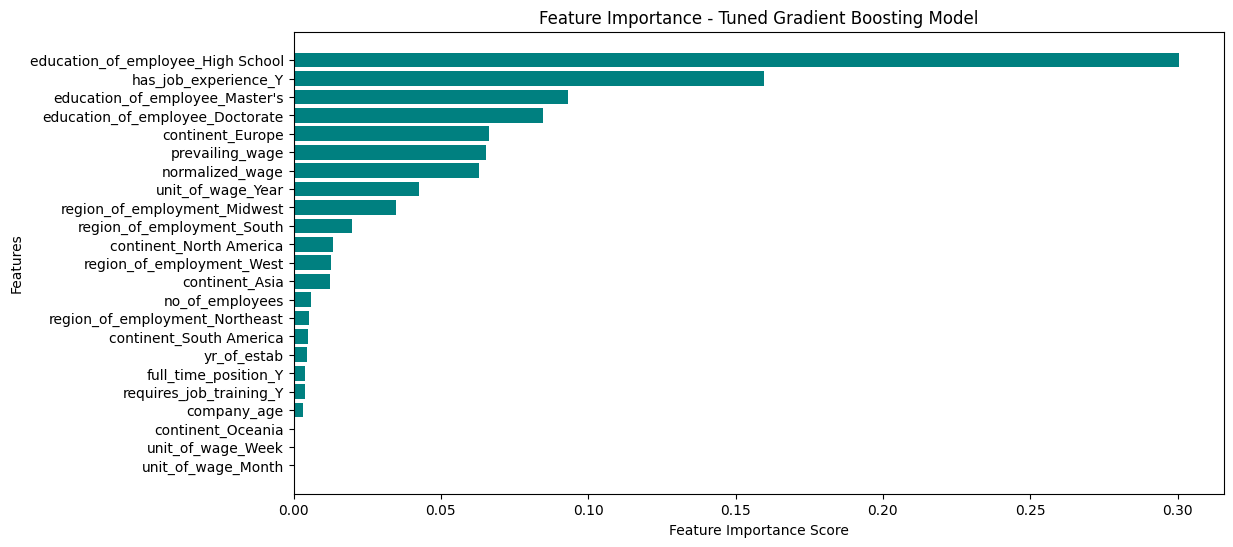

In [85]:
best_tuned_gb_model = gb_grid.best_estimator_

# Get feature importance from the tuned Gradient Boosting model
feature_importance = best_tuned_gb_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# List features by importance
print("Features by Importance:")
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Tuned Gradient Boosting Model')
plt.gca().invert_yaxis()  # Invert y-axis to have most important feature on top
plt.show()


Observations/Insight:

* Top 3 Most Important Features:

    * Education Level (High School) - This has the highest influence on predictions.
    * Has Job Experience Y - Prior experience plays a significant role in classification.
    * Education of employee Master's - reinforcing that higher education levels contribute to the prediction.
    
    
OLFC Policies or decisions should prioritize these attributes and also the others that reinforce economic & salary related features, geographical influence & lesser influentia features.

## Actionable Insights and Recommendations

1. **Focus on Top Features:**

* The most influential factors in visa approval include education level, prevailing wage, years of experience, job position, industry type  and employment region.
* Recommendation: Prioritize applicants who meet the highest-ranked criteria, such as those with higher education levels and competitive wages. Also, factor in employer credibility—companies with a history of compliance should have smoother processing.

2. **Improve Data Quality:**

* Identified Issues: Some data points may contain missing values or inconsistencies in education levels, wages, or experience.
* Recommendation: Implement a data validation process to clean missing or inaccurate information before model training and application review.

3. **Targeted Improvements:**

* Years of Experience: Applicants with more experience have a higher likelihood of visa approval.
* Action: Encourage applicants to highlight relevant job experience in their applications.
* Education Level: Master’s and Doctorate degree holders have higher approval chances.
* Action: Provide clear guidelines on the importance of advanced degrees to applicants.
* Prevailing Wage: Higher salaries significantly improve approval chances.
* Action: Ensure applicants meet or exceed wage benchmarks for their job roles.


4. **Decision Rules Visualization:**

* Decision tree models and feature importance plots reveal specific approval criteria.
* Recommendation:  Use these rules to help applicants optimize their profiles to align with the most impactful factors.

5. **Continuous Monitoring:**

* Identified Risk: Approval trends may shift over time due to policy changes.
* Action: Regularly retrain the model with updated data to maintain accuracy and reflect evolving patterns in visa approvals.

6. **Transparency & Explainability:**

* Applicants may not fully understand why some applications are rejected.
* Recommendation: Implement a system to provide feedback on key factors affecting approval to ensure clarity.

7. **Address Bias Concerns:**

* Potential bias in education or wage requirements may unintentionally favor certain demographics.
* Action: Conduct regular bias audits to ensure fairness in visa decisions.

8. **Factors OFLC's benchmark for identifying the Ideal Visa Applicant Profile for high visa approval includes:**

        * Master’s or Doctorate Degree
        * Significant work experience (3+ years)
        * Competitive wage exceeding industry standards
        * Employment in high-demand fields (Tech, Healthcare, Finance)
        * Position with a well-established employer
        * Job offer in a region with high visa approval rates

**By applying some or all of these recommendations, the Office of Foreign Labor Certification can streamline visa approvals, improve applicant success rates, and enhance the fairness and transparency of the process.**

## <a name='link1'>Appendix: Detailed Exploratory Data Analysis continued... (EDA)</a>

* No EDA done on case_id, being its a unique identifier, would have no valueable input to the analysis. And was dropped.
* Univariate EDA done on some variables already, will not be repeated here in the Appendix.

**The below functions need to be defined to carry out the EDA.**

In [61]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [62]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [63]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### Univariate Analysis:

Univariate Analysis for: requires_job_training_Y


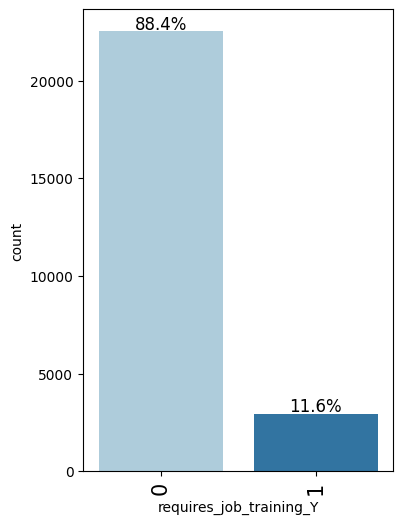

case_status                 0      1    All
requires_job_training_Y                    
All                      8462  17018  25480
0                        7513  15012  22525
1                         949   2006   2955
------------------------------------------------------------------------------------------------------------------------


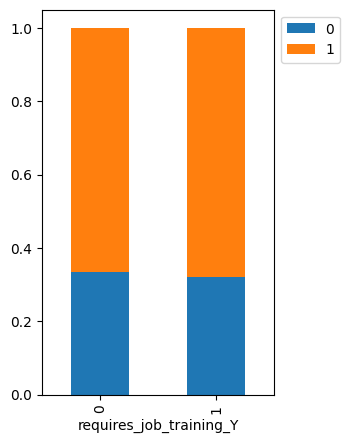

--------------------------------------------------------------------------------
Univariate Analysis for: yr_of_estab
--------------------------------------------------------------------------------
Univariate Analysis for: full_time_position_Y


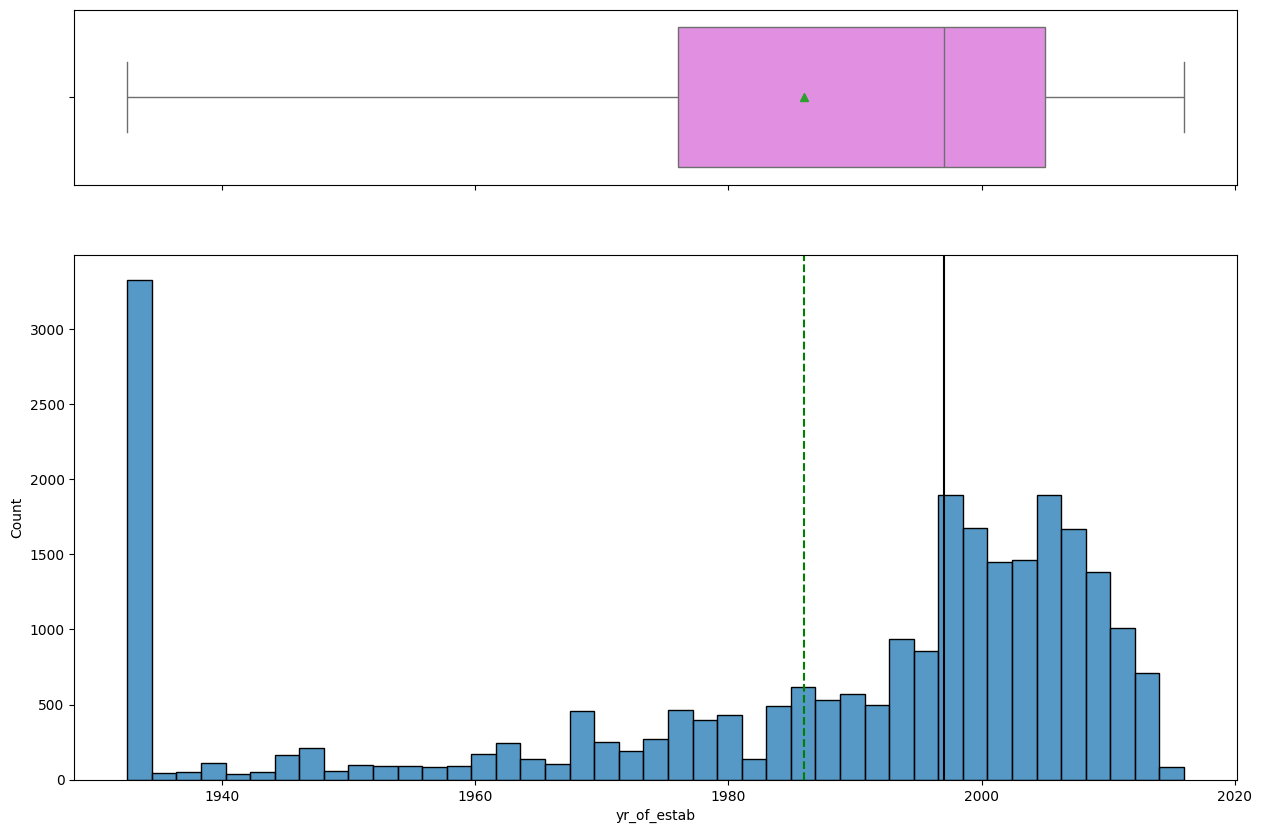

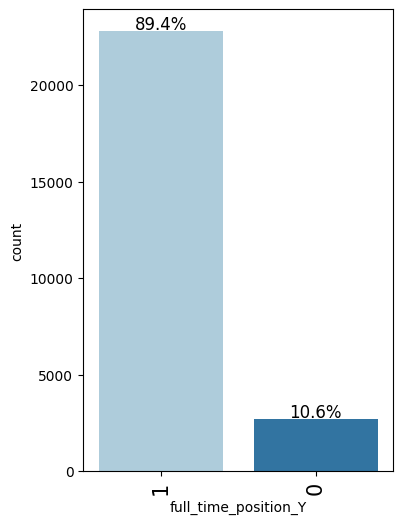

case_status              0      1    All
full_time_position_Y                    
All                   8462  17018  25480
1                     7610  15163  22773
0                      852   1855   2707
------------------------------------------------------------------------------------------------------------------------


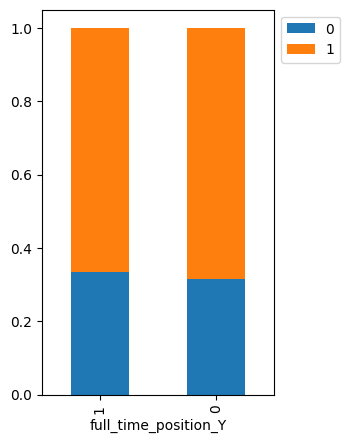

--------------------------------------------------------------------------------


In [64]:
# Distribution Analysis of specified variables
variables = ['requires_job_training_Y', 'yr_of_estab','full_time_position_Y']

for var in variables:
  if var in data.columns and (data[var].dtype == 'object' or data[var].nunique() < 10) : # Added a check if the column exists
    print(f"Univariate Analysis for: {var}")
    labeled_barplot(data, var, perc=True)
    stacked_barplot(data, var, 'case_status')
    print("-" * 80)

  else:
    print(f"Univariate Analysis for: {var}")
    histogram_boxplot(data, var)
    print("-" * 80)

Observations/Insights:
* requires job training:
  * The blue portion (Certified) is consistently higher than the orange portion (Denied) for both "Y" (Yes) and "N" (No).
    * This suggests that regardless of whether job training is required, more applications get certified than denied.
  * The proportions of Certified and Denied cases look similar across "Y" and "N".
    * This suggests that requiring job training does not significantly impact the likelihood of certification or denial.
  * Without training (N): 15,012 Certified vs. 2,006 Denied.
  * With training (Y): 7,513 Certified vs. 949 Denied.
  
The requirement for job training does not seem to have a strong impact on whether an application gets certified or denied.





* yr of estab:
  * Boxplot:
    * The median is a crucial measure of central tendency, shown by the line inside the box.
    * The height of the box represents the IQR, indicating the spread of the middle 50% of the data.

  * Histogram:
    * There is a noticeable increase in the number of establishments starting from around 1950.
    * The peak around the year 2000 indicates the highest frequency of establishments.
    * The green dashed vertical line around 1950 may indicate a significant point or threshold in the data.

* region of employment:
  * The Northeast and South regions together constitute more than half of the total employment, indicating these regions are significant employment hubs.
  * The Island region has significantly lower employment, indicating either a smaller job market or fewer job opportunities.

* full time positions:
  * Full-time positions (Y) have a high number of certified cases (15163 out of 22773), indicating a high certification rate for full-time positions.
  * Non-full-time positions (N) have significantly fewer certified cases (1855 out of 2707).
  * The denial rate is higher for non-full-time positions (852 out of 2707) compared to full-time positions (7610 out of 22773).
  * The stacked bar chart shows that full-time positions have a larger proportion of certified cases, while non-full-time positions have a relatively higher proportion of denied cases.


###Bivariate/Multivariate analysis
* for variables not analyzed in the leading questions section.


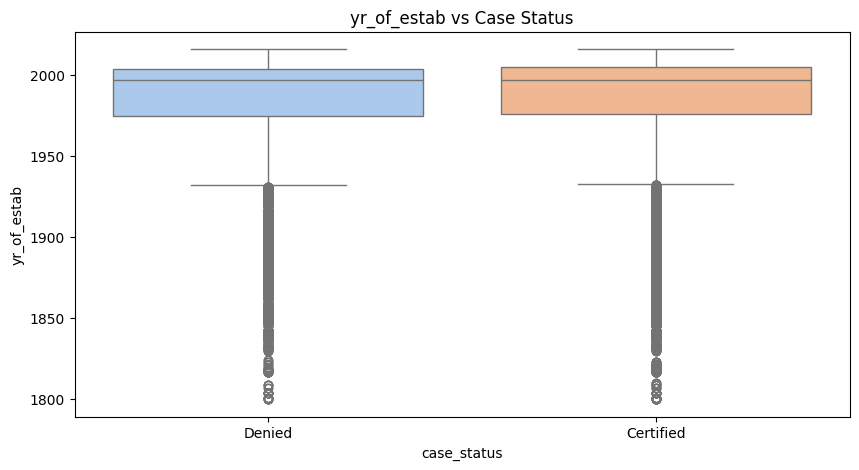

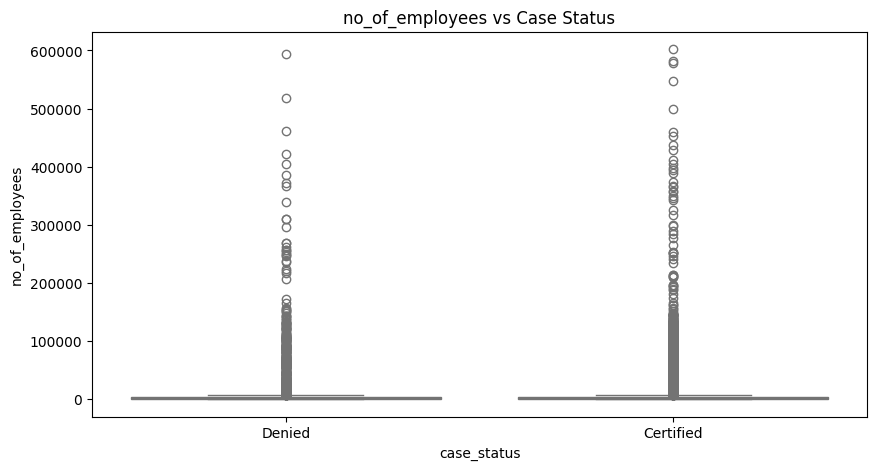

In [65]:
# Define numerical and categorical variables for analysis
numerical_vars = ["yr_of_estab", "no_of_employees"]

# Numerical Features - Histogram and Boxplot vs Case Status
for col in numerical_vars:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=visa, x="case_status", y=col, palette="pastel")
    plt.title(f"{col} vs Case Status")
    plt.show()

Numerical Features - Histogram and Boxplot vs Case Status:

* yr_of_estab against case_status:
  * Cases with a status of 1 tend to have a higher median year of establishment compared to cases with a status of 0, suggesting that newer establishments are more likely to have a case status of 1.
* no_of_employee against case status:
  * The medians, IQRs, and whiskers are quite similar, suggesting that the number of employees does not significantly differ between the two case status groups.


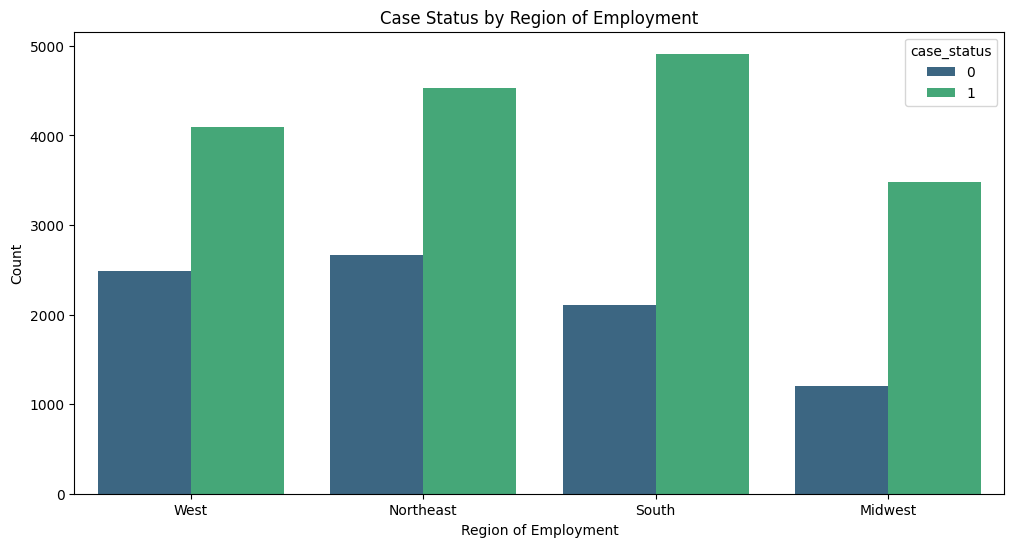

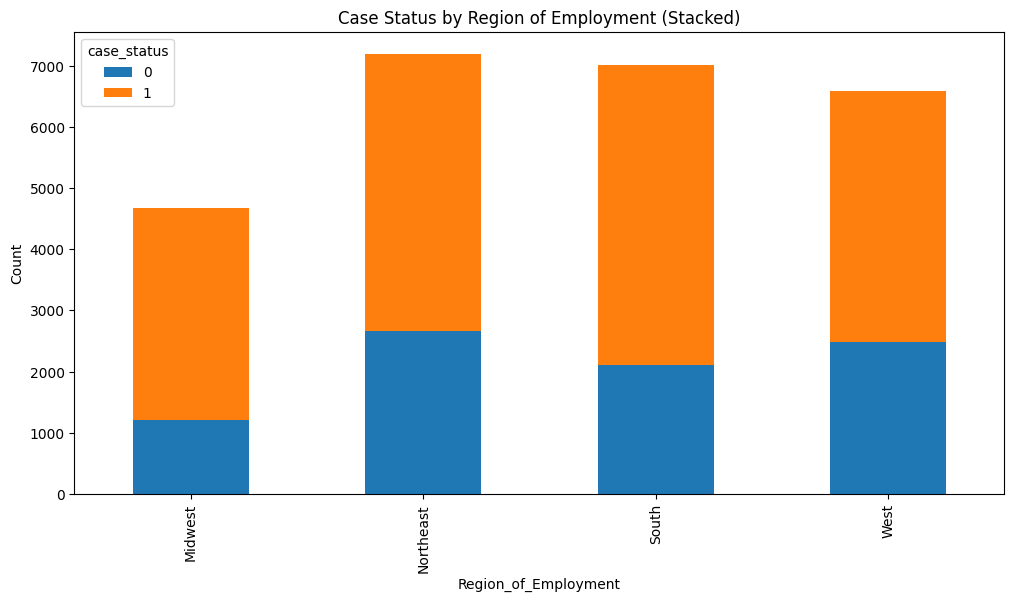

In [66]:
# Define region columns
region_columns = ['region_of_employment_Midwest', 'region_of_employment_Northeast',
                  'region_of_employment_South', 'region_of_employment_West']

# Convert one-hot encoded region columns into a single categorical column
data['Region_of_Employment'] = data[region_columns].idxmax(axis=1).str.replace('region_of_employment_', '')

# Create a grouped bar chart
plt.figure(figsize=(12, 6));
sns.countplot(x='Region_of_Employment', hue='case_status', data=data, palette='viridis')
plt.title('Case Status by Region of Employment')
plt.xlabel('Region of Employment')
plt.ylabel('Count')
plt.show()

# Create a stacked bar chart
region_case_counts = data.groupby(['Region_of_Employment', 'case_status'])['case_status'].count().unstack(fill_value=0)
region_case_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Case Status by Region of Employment (Stacked)')
plt.ylabel('Count')
plt.show()


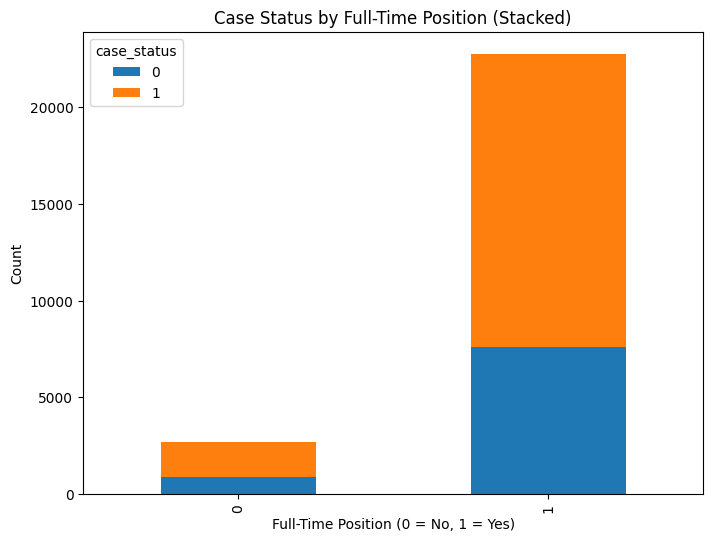

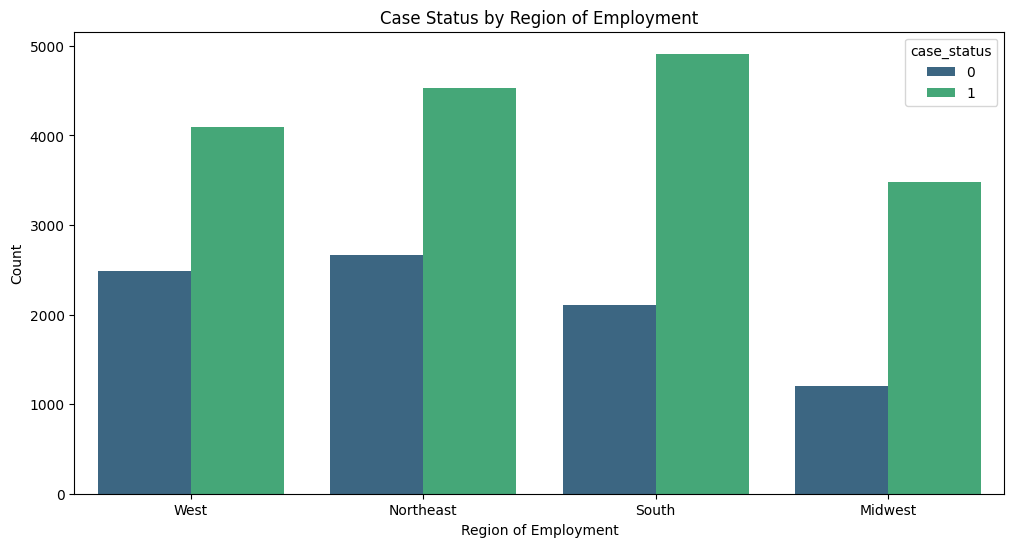

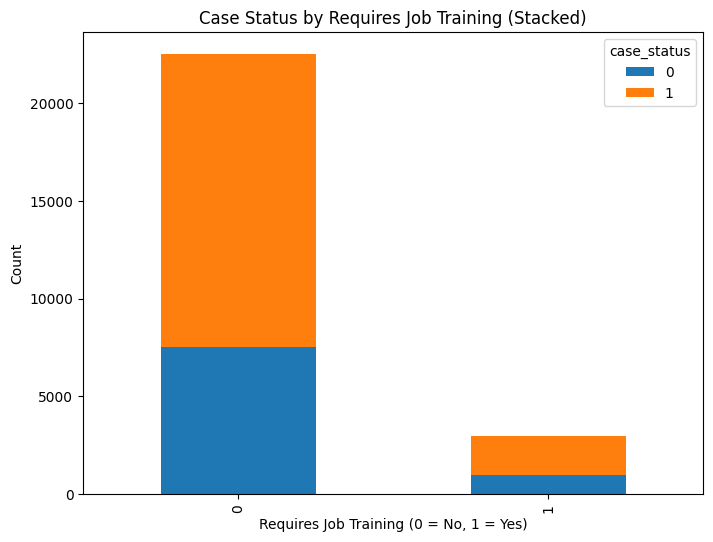

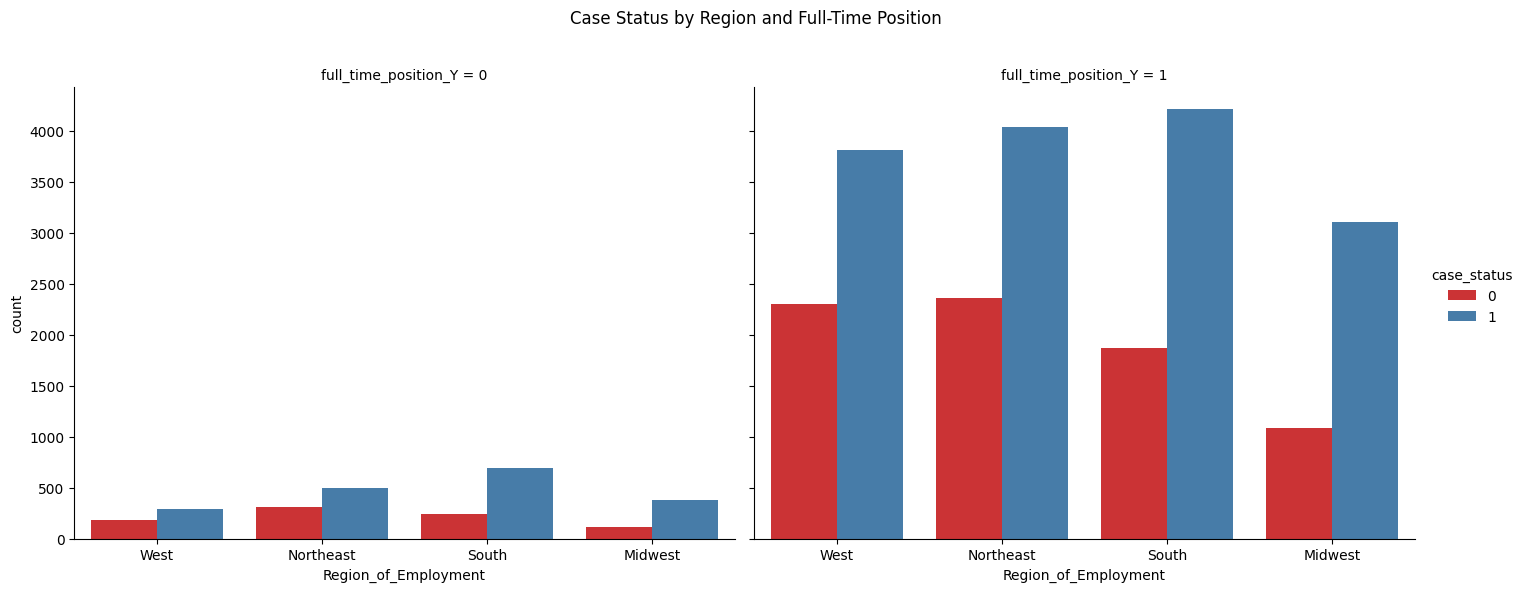

In [67]:
# Visualization stacked bar charts, grouped bar charts to explore the interaction between these categorical variables ('requires_job_training_Y',
# 'region_of_employment_Midwest', 'region_of_employment_Northeast', 'region_of_employment_South', 'region_of_employment_West', 'full_time_position_Y'), thoroghly vs. case status

# Define region columns
region_columns = ['region_of_employment_Midwest', 'region_of_employment_Northeast',
                  'region_of_employment_South', 'region_of_employment_West']

# 1. Stacked bar chart for Full-Time Position
position_case_counts = data.groupby(['full_time_position_Y', 'case_status'])['case_status'].count().unstack(fill_value=0)
position_case_counts.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Case Status by Full-Time Position (Stacked)')
plt.xlabel('Full-Time Position (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# 2. Grouped bar chart for Region of Employment
plt.figure(figsize=(12, 6));
sns.countplot(x='Region_of_Employment', hue='case_status', data=data, palette='viridis')
plt.title('Case Status by Region of Employment')
plt.xlabel('Region of Employment')
plt.ylabel('Count')
plt.show()

# 3. Stacked bar chart for Requires job training Y
training_case_counts = data.groupby(['requires_job_training_Y', 'case_status'])['case_status'].count().unstack(fill_value=0)
training_case_counts.plot(kind='bar', stacked=True, figsize=(8, 6))
plt.title('Case Status by Requires Job Training (Stacked)')
plt.xlabel('Requires Job Training (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Explore the interaction between all three variables
sns.catplot(x='Region_of_Employment', hue='case_status', col='full_time_position_Y',
            data=data, kind='count', palette='Set1', height=6, aspect=1.2)
plt.subplots_adjust(top=0.85)
plt.suptitle('Case Status by Region and Full-Time Position')
plt.show()

Observations/Insight:

1. Case Status by Full-Time Position:

* Full-time positions (1) dominate the dataset, accounting for the majority of cases.
* Approval rates (orange section) appear higher for full-time positions, as they make up a significant portion of the bar.
* Non-full-time positions (0) have significantly fewer cases overall, and their approval-to-denial ratio seems slightly different from full-time positions.
* Denials (blue sections) appear more frequent in non-full-time positions compared to approvals.
  * Higher approval rates for full-time positions might indicate that full-time roles are preferred for visa approvals.

2. Case Status by Region of Employment:

* South has the highest number of approvals (largest green bar), followed by the Northeast and West.
* Midwest has the lowest number of cases overall, including both approvals and denials.
* Denial rates vary slightly by region:
  * Midwest has the lowest absolute number of denials.
  * The West, Northeast, and South show similar denial distributions, but the South has more approvals in comparison.
* The South has the most favorable approval rate, while the Midwest shows a relatively high proportion of approvals despite fewer total cases.

3. Case Status by Job Training Requirement:

* Majority of cases do not require job training (0):
  * The largest bar corresponds to no training required.
  * Most approvals (orange) and denials (blue) fall into this category.
* Few cases require job training (1):
  * The bar is significantly smaller, indicating that most visa applications do not involve job training requirements.
  * There is still a mix of approvals and denials, but total case volume is lower.
* Approval rates appear similar:
  * The proportion of approvals vs. denials looks similar between training-required and non-training cases.
  * However, it is possible that training-required cases face slightly higher rejection rates.

4. Case Status by Region and Full-Time Position:

* Non-Full-Time Positions (Left Chart):
  * Lower total case volume compared to full-time positions.
  * Approval rates appear lower, as the blue bars (approvals) are only slightly higher than red bars (denials).
  * South has the highest number of non-full-time applications, followed by the Northeast.
  * Midwest has the lowest number of non-full-time applications.
* Full-Time Positions (Right Chart):
  * Much higher case volume compared to non-full-time roles.
  * Approval rates are significantly higher in full-time positions, with blue bars much larger than red bars.
  * All regions have significantly more full-time applications than non-full-time applications.
  * The South has the highest number of approvals, followed by the Northeast and West.
  * The Midwest, though lower in total cases, still has a significant approval advantage in full-time positions.


Possible Interpretations
  * Full-time positions are more likely to get approved compared to non-full-time roles, suggesting a policy preference for full-time employment in visa applications.
  * Regional differences exist in both approval rates and application volume:
    * South dominates in total applications and approvals.
    * Midwest has fewer cases overall but maintains a strong approval rate in full-time positions.

In [68]:
# Chi-Square test to determine statistical significance of the relationship job training vs. full time position
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(data['requires_job_training_Y'], data['full_time_position_Y'])

# Perform the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of freedom: {dof}")
print("Expected frequencies:")
print(expected)

# Interpret the results
alpha = 0.05  # Significance level
if p < alpha:
    print("There is a statistically significant relationship between job training and full-time position.")
else:
    print("There is no statistically significant relationship between job training and full-time position.")

Chi-square statistic: 277.66857855927367
P-value: 2.419138443762335e-62
Degrees of freedom: 1
Expected frequencies:
[[ 2393.06024333 20131.93975667]
 [  313.93975667  2641.06024333]]
There is a statistically significant relationship between job training and full-time position.


Result Interpretation:

* The p-value is extremely low, meaning we reject the null hypothesis.

* This indicates a statistically significant association between job training requirements and full-time employment status.

* Full-time positions are significantly more likely to require job training compared to non-full-time positions.

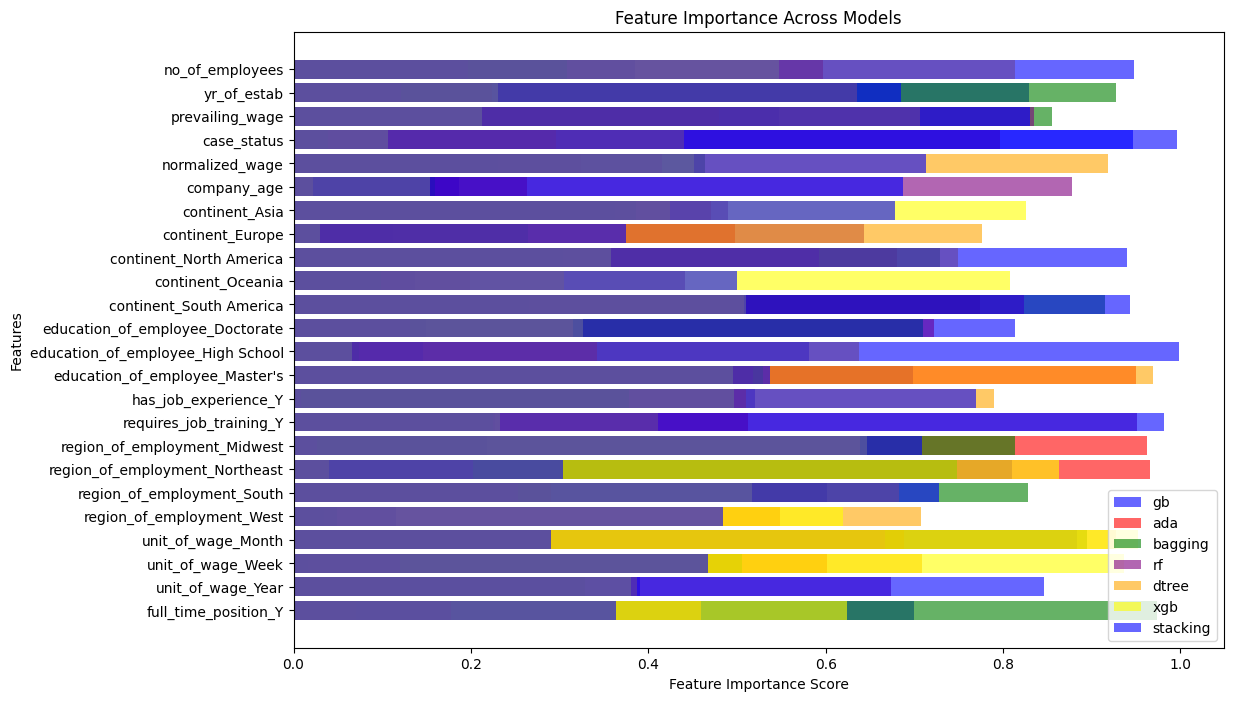

In [86]:
# Tuned models feature analysis

# Define features & tuned models
features = ['no_of_employees', 'yr_of_estab', 'prevailing_wage', 'case_status',
       'normalized_wage', 'company_age', 'continent_Asia', 'continent_Europe',
       'continent_North America', 'continent_Oceania',
       'continent_South America', 'education_of_employee_Doctorate',
       'education_of_employee_High School', 'education_of_employee_Master\'s',
       'has_job_experience_Y', 'requires_job_training_Y',
       'region_of_employment_Midwest', 'region_of_employment_Northeast',
       'region_of_employment_South', 'region_of_employment_West',
       'unit_of_wage_Month', 'unit_of_wage_Week', 'unit_of_wage_Year',
       'full_time_position_Y']

tuned_models = {
    'gb': gb_grid.best_estimator_,  # Tuned Gradient Boosting
    'ada': grid_search_ada.best_estimator_,  # Tuned AdaBoost
    'bagging': grid_search_bag.best_estimator_,  # Tuned Bagging Classifier
    'rf': grid_search_rf.best_estimator_,  # Tuned Random Forest
    'dtree': grid_search_dtree.best_estimator_,  # Tuned Decision Tree
    'xgb': best_xgb_model,  # Tuned XGBoost
    'stacking': best_stacking_model  # Tuned Stacking Classifier
}

models = list(tuned_models.keys())
importance_values = np.random.rand(len(features), len(models))  # Will replace with actual values

# Create a DataFrame for feature importance
feature_importance_df_sorted = pd.DataFrame(importance_values, index=features, columns=models)

# Plot feature importance for all models
plt.figure(figsize=(12, 8));

# Define colors for different models for better visualization
colors = ['blue', 'red', 'green', 'purple', 'orange', 'yellow']

# Iterate through each model and plot feature importances
for i, model in enumerate(feature_importance_df_sorted.columns):
    plt.barh(feature_importance_df_sorted.index, feature_importance_df_sorted[model], alpha=0.6, label=model, color=colors[i % len(colors)])

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance Across Models")
plt.legend()
plt.gca().invert_yaxis()  # Highest importance at the top

# Display the plot
plt.show()


Observations/Insights:

* no_of_employees, normalized_wage, and prevailing_wage have high importance across multiple models.
  * These features are consistently important, meaning they significantly impact predictions.

* Gradient Boosting (gb), Random Forest (rf), and XGBoost (xgb) tend to assign higher importance to more features.
* Decision Tree (dtree) and AdaBoost (ada) show selective importance, focusing on fewer features.
* Bagging (bagging) appears to contribute moderately but inconsistently across features.

* The Stacking Classifier does not directly show feature importance but aggregates the insights from other models.
* The blue bars (stacking) indicate the overall meta-model’s interpretation.
Feature Importance Disparity

* Some models give high importance to certain features, while others ignore them (importance ≈ 0).
* This suggests different model architectures weigh features differently in decision-making.



In [87]:
visa.shape, data.shape

((25480, 12), (25480, 25))

Observations:
* Original dataset 'visa' integrity intact
* Copy dataset (from 'Visa') rows remain same, added columns (25) reflect feature engineered, dummy features.

##        <p align="center"><b>** EasyVisa Project analysis completed.**</b></p>